# Deliverable 1: Data Analysis
## Parkinson's Disease Detection via Gait Signals
**Project:** State Space Models (Mamba/SSM) for Medical Time Series Analysis  
**Dataset:** PhysioNet — [Gait in Parkinson's Disease](https://physionet.org/content/gaitpdb/1.0.0/)  
**Author:** [Your Name] | FAU Erlangen-Nürnberg  
**Date:** May 2026

---
### Deliverable Requirements
1. Report demographics (patients, controls, age, sex) — from full Excel **and** from fold files  
2. Plot raw signal examples (PD vs HC)  
3. Extract TSFresh features + PCA / t-SNE plots (z-score normalised)  
4. Per-subject statistics: mean, std, skewness, kurtosis  
5. Three PCA/t-SNE sets: right foot / left foot / combined  
6. Alternative approaches (free choice — UMAP, statistical tests, heatmaps)

> **Note:** Z-score normalisation is applied to the feature matrix **before** PCA/t-SNE (sklearn `StandardScaler`)


## 0. Setup & Imports

In [ ]:
# Install required packages (run once)
# !pip install tsfresh scikit-learn scipy matplotlib seaborn pandas numpy xlrd umap-learn


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from scipy.signal import resample


# ── CONFIG ──────────────────────────────────────────────────────────────────
DATA_DIR   = "./Data"   # path to extracted Data.zip
ZIP_PATH   = None         # set None if already extracted
OUTPUT_DIR = "./deliverable1_outputs_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Window settings (deliverable spec)
WINDOW_SEC     = 5.0     # seconds
STEP_SEC       = 2.5     # seconds  (50% overlap)
SAMPLE_RATE    = 100     # Hz
WINDOW_SAMPLES = int(WINDOW_SEC  * SAMPLE_RATE)  # 500
STEP_SAMPLES   = int(STEP_SEC    * SAMPLE_RATE)  # 250

# Column names (PhysioNet gaitpdb format)
LEFT_COLS   = [f"L{i}" for i in range(1, 9)]
RIGHT_COLS  = [f"R{i}" for i in range(1, 9)]
TOTAL_LEFT  = "TotalLeft"
TOTAL_RIGHT = "TotalRight"
ALL_COLS    = LEFT_COLS + RIGHT_COLS + [TOTAL_LEFT, TOTAL_RIGHT]

# Colour palettes
PALETTE    = {"PD": "#E63946", "HC": "#457B9D"}
COHORT_PAL = {"Ga": "#2A9D8F", "Ju": "#E9C46A", "Si": "#F4A261"}
HY_PAL     = {2.0: "#fee090", 2.5: "#fc8d59", 3.0: "#d73027"}

print("Setup complete ✅")
print(f"Window: {WINDOW_SEC}s | Step: {STEP_SEC}s | SR: {SAMPLE_RATE}Hz")


Setup complete ✅
Window: 5.0s | Step: 2.5s | SR: 100Hz


---
## 1. Data Loading

The dataset is extracted from `Data.zip`. We use only the **`_01.txt`** files (normal walking condition) from `splits/Fold_1/` to define our subject list.


In [5]:
import zipfile

def extract_zip_if_needed(zip_path, dest):
    if not os.path.exists(os.path.join(dest, "demographics.xls")):
        print(f"Extracting {zip_path} → {dest}")
        os.makedirs(dest, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(dest)
    else:
        print(f"Already extracted: {dest}")

def load_demographics(base_dir):
    path = os.path.join(base_dir, "demographics.xls")
    df = pd.read_excel(path, engine="xlrd")
    df["label"]  = df["Group"].map({"PD": "PD", "CO": "HC"})
    df["cohort"] = df["Study"]
    mask_cm = df["Height (meters)"] > 10  # Ju cohort uses cm
    df.loc[mask_cm, "Height (meters)"] /= 100
    return df

def collect_all_files(base_dir, folder="Fold_1"):
    search_dirs = [
        os.path.join(base_dir, "splits", folder, "training"),
        os.path.join(base_dir, "splits", folder, "test"),
        os.path.join(base_dir, "splits", folder, "validation"),
    ]
    seen, records = set(), []
    for d in search_dirs:
        for fname in sorted(os.listdir(d)):
            if not fname.endswith("_01.txt"):
                continue
            sid = fname.replace("_01.txt", "")
            if sid in seen:
                continue
            seen.add(sid)
            records.append({
                "subject_id": sid,
                "label":  "PD" if "Pt" in sid else "HC",
                "cohort": sid[:2],
                "filepath": os.path.join(d, fname),
                "fileType": "training" if "training" in d else ("test" if "test" in d else "validation")
            })
    return pd.DataFrame(records)

def load_signal(filepath):
    cols = ["Time"] + LEFT_COLS + RIGHT_COLS + [TOTAL_LEFT, TOTAL_RIGHT]
    return pd.read_csv(filepath, sep=r"\s+", header=None, names=cols)

# Run loading
if ZIP_PATH and os.path.exists(ZIP_PATH):
    extract_zip_if_needed(ZIP_PATH, DATA_DIR)

demo_df  = load_demographics(DATA_DIR)
file_df  = collect_all_files(DATA_DIR, folder="Fold_1")

print(f"\nFold 1 subjects: {len(file_df)} total")
print(f"  PD: {(file_df['label']=='PD').sum()}  |  HC: {(file_df['label']=='HC').sum()}")
print(f"  Cohorts: {file_df['cohort'].value_counts().to_dict()}")
print(f"\nFull dataset (Excel): {len(demo_df)} subjects")
print(f"  PD: {(demo_df['label']=='PD').sum()}  |  HC: {(demo_df['label']=='HC').sum()}")



Fold 1 subjects: 100 total
  PD: 50  |  HC: 50
  Cohorts: {'Si': 37, 'Ju': 32, 'Ga': 31}

Full dataset (Excel): 166 subjects
  PD: 93  |  HC: 73


---
## 2. Demographics

We show demographics from two sources:
1. **Full dataset** — from `demographics.xls` (N=166)
2. **Fold 1** — from the actual data files in `splits/Fold_1/` (N=80)


In [ ]:
# ── 2A. Full dataset demographics (from demographics.xls) ─────────────────

def demographics_summary(df, title):
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    for lbl, sub in [("Overall", df), ("PD", df[df["label"]=="PD"]), ("HC", df[df["label"]=="HC"])]:
        n   = len(sub)
        m   = (sub["Gender"]=="male").sum()
        f   = (sub["Gender"]=="female").sum()
        age = sub["Age"].dropna()
        print(f"  {lbl} (n={n}): M/F={m}/{f}  Age={age.mean():.1f}±{age.std():.1f}")
    
    pd_d = df[df["label"]=="PD"]
    hy   = pd_d["HoehnYahr"].dropna()
    print(f"\n  H&Y distribution (PD): ", {k:v for k,v in hy.value_counts().sort_index().items()})
    print(f"  H&Y mean±SD: {hy.mean():.2f} ± {hy.std():.2f}")
    
    print(f"\n  Per cohort:")
    for coh in ["Ga","Si","Ju"]:
        sub = df[df["cohort"]==coh]
        print(f"    {coh}: PD={(sub['label']=='PD').sum()}, HC={(sub['label']=='HC').sum()}, "
              f"Total={len(sub)}, Age={sub['Age'].mean():.0f}±{sub['Age'].std():.0f}")

demographics_summary(demo_df, "FULL DATASET — demographics.xls (N=166)")

# Fold 1 merged
fold_merged = file_df.merge(
    demo_df[["ID","Gender","Age","Height (meters)","Weight (kg)","HoehnYahr","UPDRS","UPDRSM"]],
    left_on="subject_id", right_on="ID", how="left"
)
demographics_summary(fold_merged.rename(columns={"label":"label"}),
                     "FOLD 1 SUBJECTS — splits/Fold_1/ (N=100)")



  FULL DATASET — demographics.xls (N=166)
  Overall (n=166): M/F=98/68  Age=65.1±9.2
  PD (n=93): M/F=58/35  Age=66.3±9.5
  HC (n=73): M/F=40/33  Age=63.7±8.6

  H&Y distribution (PD):  {2.0: 55, 2.5: 28, 3.0: 10}
  H&Y mean±SD: 2.26 ± 0.34

  Per cohort:
    Ga: PD=29, HC=18, Total=47, Age=71±7
    Si: PD=35, HC=29, Total=64, Age=60±8
    Ju: PD=29, HC=26, Total=55, Age=66±8

  FOLD 1 SUBJECTS — splits/Fold_1/ (N=100)
  Overall (n=100): M/F=50/50  Age=64.8±9.2
  PD (n=50): M/F=25/25  Age=66.5±9.8
  HC (n=50): M/F=25/25  Age=63.0±8.4

  H&Y distribution (PD):  {2.0: 26, 2.5: 16, 3.0: 8}
  H&Y mean±SD: 2.32 ± 0.37

  Per cohort:
    Ga: PD=18, HC=13, Total=31, Age=71±7
    Si: PD=16, HC=21, Total=37, Age=59±8
    Ju: PD=16, HC=16, Total=32, Age=65±8


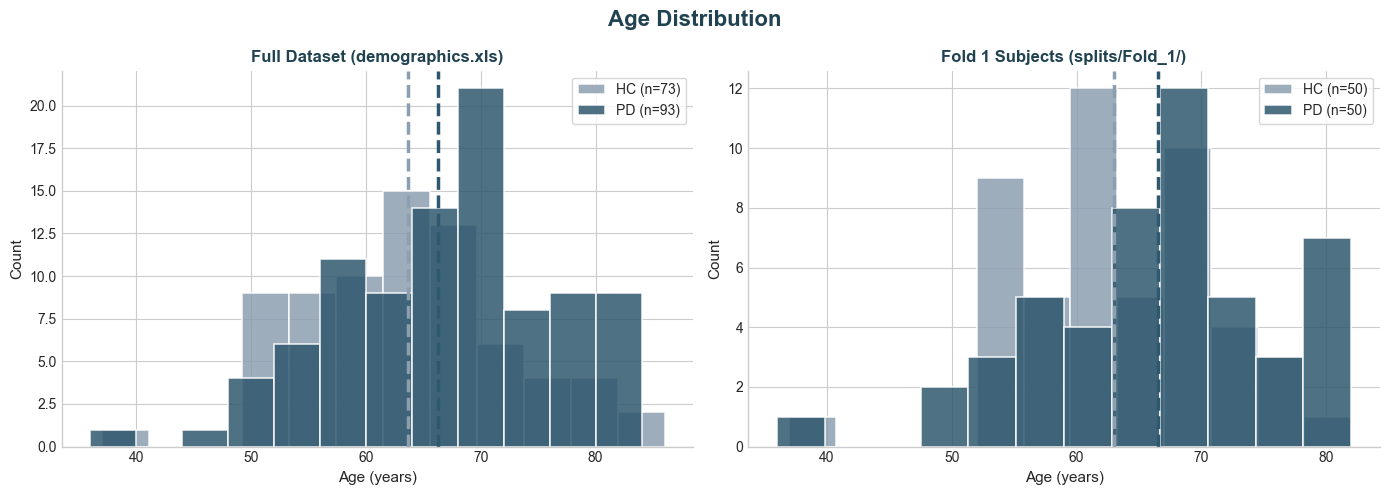

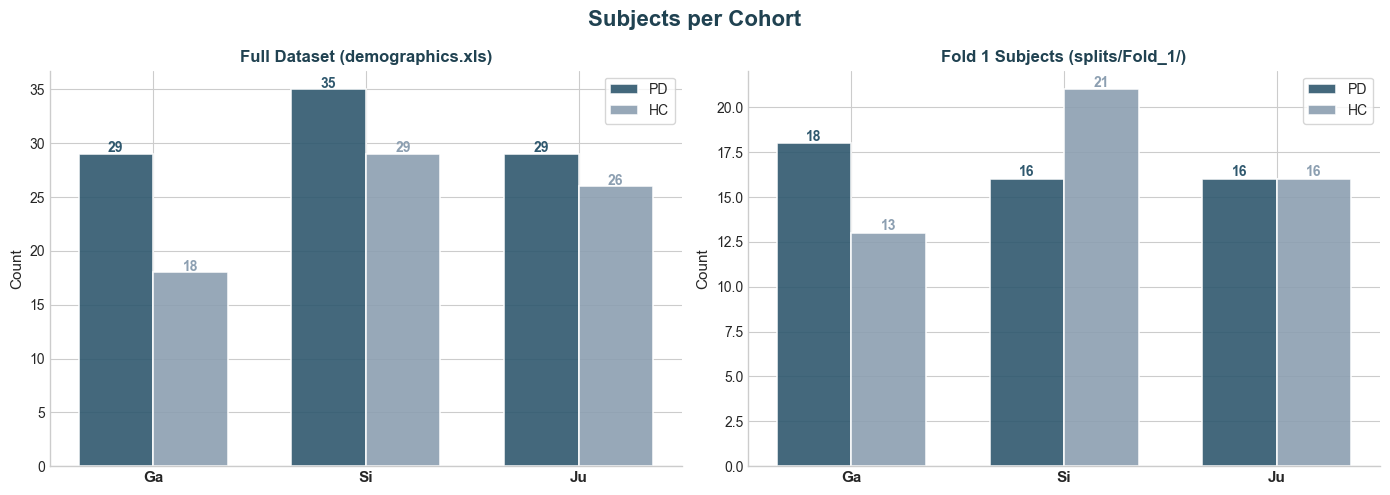

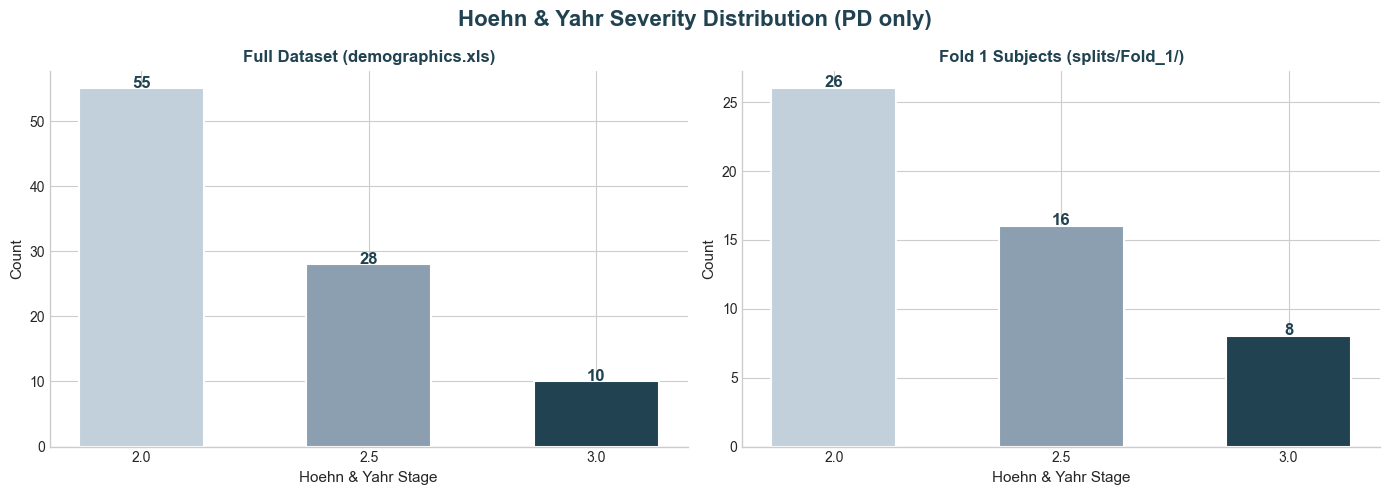


⚠ NOTE: 3 sub-cohorts collected under different conditions:
  Ga = normal walk
  Si = treadmill
  Ju = rhythmic auditory stimulation (RAS)

This is a known confound — check PCA panel B for cohort separation.


In [8]:
# ── 2B. Demographics visualisation ─────────────────────────────────────────

# =========================================================
# STYLE + COLOR PALETTE
# =========================================================

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "gray":       "#7F7F7F",
    "navy":       "#204251",
    "blue":       "#2F586E",
    "lightblue":  "#8C9FB1",
    "lightgray":  "#C2D0DC",
    "silver":     "#C7C7C7",
}

PD_COLOR = COLORS["blue"]
HC_COLOR = COLORS["lightblue"]

HY_COLORS = [
    COLORS["lightgray"],
    COLORS["lightblue"],
    COLORS["navy"],
]

datasets = [
    (demo_df,     "Full Dataset (demographics.xls)", 166),
    (fold_merged, "Fold 1 Subjects (splits/Fold_1/)", 100),
]

# =========================================================
# 1. AGE DISTRIBUTION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Age Distribution",
    fontsize=16,
    fontweight="bold",
    color=COLORS["navy"]
)

for row_i, (src_df, src_label, N) in enumerate(datasets):

    pd_d = src_df[src_df["label"] == "PD"]
    hc_d = src_df[src_df["label"] == "HC"]

    ax = axes[row_i]

    ax.hist(
        hc_d["Age"].dropna(),
        bins=12,
        color=HC_COLOR,
        alpha=0.85,
        label=f"HC (n={len(hc_d)})",
        edgecolor="white",
        linewidth=1.2
    )

    ax.hist(
        pd_d["Age"].dropna(),
        bins=12,
        color=PD_COLOR,
        alpha=0.85,
        label=f"PD (n={len(pd_d)})",
        edgecolor="white",
        linewidth=1.2
    )

    ax.axvline(
        hc_d["Age"].mean(),
        color=HC_COLOR,
        lw=2.5,
        ls="--"
    )

    ax.axvline(
        pd_d["Age"].mean(),
        color=PD_COLOR,
        lw=2.5,
        ls="--"
    )

    ax.set_title(
        src_label,
        fontsize=12,
        fontweight="bold",
        color=COLORS["navy"]
    )

    ax.set_xlabel("Age (years)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)

    ax.legend(fontsize=10, frameon=True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/fig_age_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 2. COHORT DISTRIBUTION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    "Subjects per Cohort",
    fontsize=16,
    fontweight="bold",
    color=COLORS["navy"]
)

for row_i, (src_df, src_label, N) in enumerate(datasets):

    pd_d = src_df[src_df["label"] == "PD"]
    hc_d = src_df[src_df["label"] == "HC"]

    ax = axes[row_i]

    cohorts = ["Ga", "Si", "Ju"]

    x = np.arange(3)
    w = 0.35

    pd_c = [len(pd_d[pd_d["cohort"] == c]) for c in cohorts]
    hc_c = [len(hc_d[hc_d["cohort"] == c]) for c in cohorts]

    ax.bar(
        x - w/2,
        pd_c,
        w,
        color=PD_COLOR,
        label="PD",
        alpha=0.9,
        edgecolor="white",
        linewidth=1.2
    )

    ax.bar(
        x + w/2,
        hc_c,
        w,
        color=HC_COLOR,
        label="HC",
        alpha=0.9,
        edgecolor="white",
        linewidth=1.2
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        cohorts,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_title(
        src_label,
        fontsize=12,
        fontweight="bold",
        color=COLORS["navy"]
    )

    ax.set_ylabel("Count", fontsize=11)

    ax.legend(fontsize=10, frameon=True)

    for i, (p, h) in enumerate(zip(pd_c, hc_c)):

        ax.text(
            i - w/2,
            p + 0.15,
            str(p),
            ha="center",
            fontsize=10,
            color=PD_COLOR,
            fontweight="bold"
        )

        ax.text(
            i + w/2,
            h + 0.15,
            str(h),
            ha="center",
            fontsize=10,
            color=HC_COLOR,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/fig_cohort_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 3. H&Y SEVERITY DISTRIBUTION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    "Hoehn & Yahr Severity Distribution (PD only)",
    fontsize=16,
    fontweight="bold",
    color=COLORS["navy"]
)

for row_i, (src_df, src_label, N) in enumerate(datasets):

    pd_d = src_df[src_df["label"] == "PD"]

    ax = axes[row_i]

    hy = (
        pd_d["HoehnYahr"]
        .dropna()
        .value_counts()
        .sort_index()
    )

    if len(hy):

        bars = ax.bar(
            [str(v) for v in hy.index],
            hy.values,
            color=HY_COLORS[:len(hy)],
            edgecolor="white",
            linewidth=1.5,
            width=0.55
        )

        for bar, v in zip(bars, hy.values):

            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                str(v),
                ha="center",
                fontsize=12,
                fontweight="bold",
                color=COLORS["navy"]
            )

    ax.set_title(
        src_label,
        fontsize=12,
        fontweight="bold",
        color=COLORS["navy"]
    )

    ax.set_xlabel(
        "Hoehn & Yahr Stage",
        fontsize=11
    )

    ax.set_ylabel(
        "Count",
        fontsize=11
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/fig_hy_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# NOTE
# =========================================================

print("\n⚠ NOTE: 3 sub-cohorts collected under different conditions:")

print("  Ga = normal walk")
print("  Si = treadmill")
print("  Ju = rhythmic auditory stimulation (RAS)")

print("\nThis is a known confound — check PCA panel B for cohort separation.")


---
## 3. Raw Signal Visualisation

We plot 15 seconds of total vertical ground reaction force for 3 PD and 3 HC subjects.  
**CV (Coefficient of Variation)** = std/mean × 100 — higher CV indicates more irregular gait.


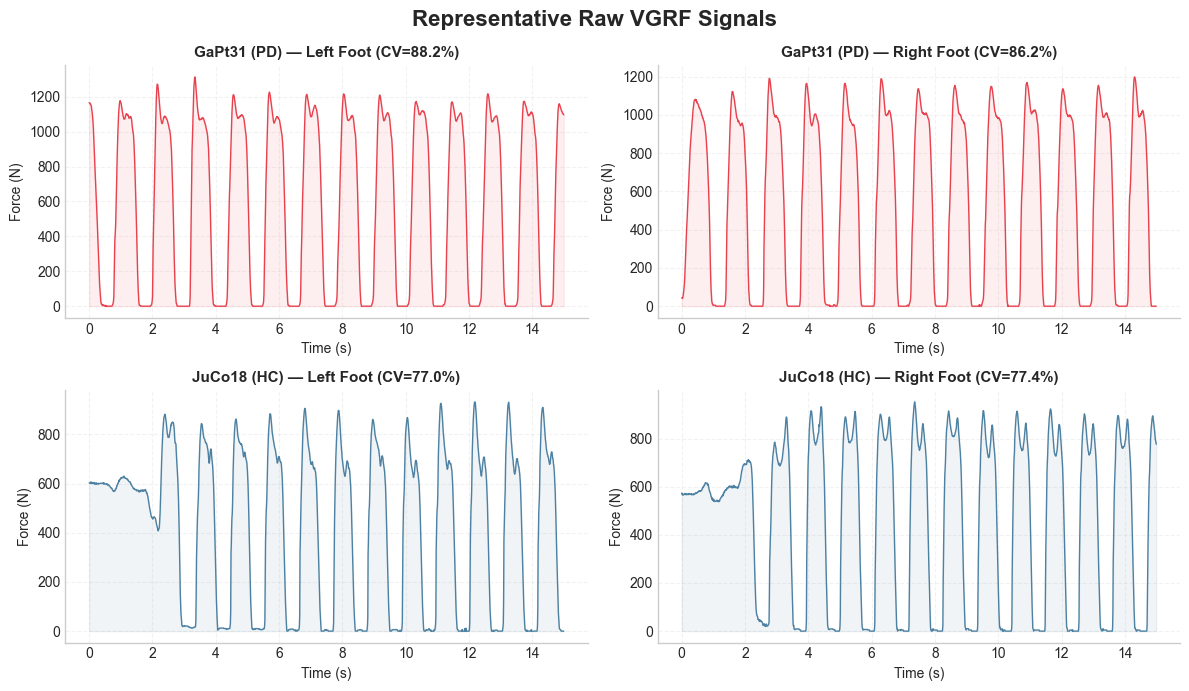

In [13]:
PALETTE    = {"PD": "#E63946", "HC": "#457B9D"}
def plot_representative_raw_signals(file_df, save=True):

    pd_subject = (
        file_df[file_df["label"] == "PD"]
        .sample(1, random_state=42)
        .iloc[0]
    )

    hc_subject = (
        file_df[file_df["label"] == "HC"]
        .sample(1, random_state=42)
        .iloc[0]
    )

    SHOW = 15 * SAMPLE_RATE

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))

    fig.suptitle(
        "Representative Raw VGRF Signals",
        fontsize=16,
        fontweight="bold"
    )

    subjects = [
        (pd_subject, 0, "PD"),
        (hc_subject, 1, "HC")
    ]

    for row, row_idx, label in subjects:

        sig = load_signal(row["filepath"])

        t = sig["Time"].values[:SHOW]

        color = PALETTE[label]

        for col_idx, (force_col, foot) in enumerate([
            (TOTAL_LEFT, "Left Foot"),
            (TOTAL_RIGHT, "Right Foot")
        ]):

            ax = axes[row_idx, col_idx]

            y = sig[force_col].values[:SHOW]

            ax.plot(
                t,
                y,
                color=color,
                lw=1,
                alpha=0.95
            )
            ax.grid(
                linestyle="--",
                alpha=0.25
            )
            ax.fill_between(
                t,
                y,
                color=color,
                alpha=0.08
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            

            cv = np.std(y) / (np.mean(y) + 1e-8) * 100

            ax.set_title(
                f"{row['subject_id']} ({label}) — {foot} (CV={cv:.1f}%)",
                fontsize=11,
                fontweight="bold"
            )

            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Force (N)")

    plt.tight_layout()

    if save:
        plt.savefig(
            f"{OUTPUT_DIR}/fig_representative_raw_signals.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    
plot_representative_raw_signals(file_df)

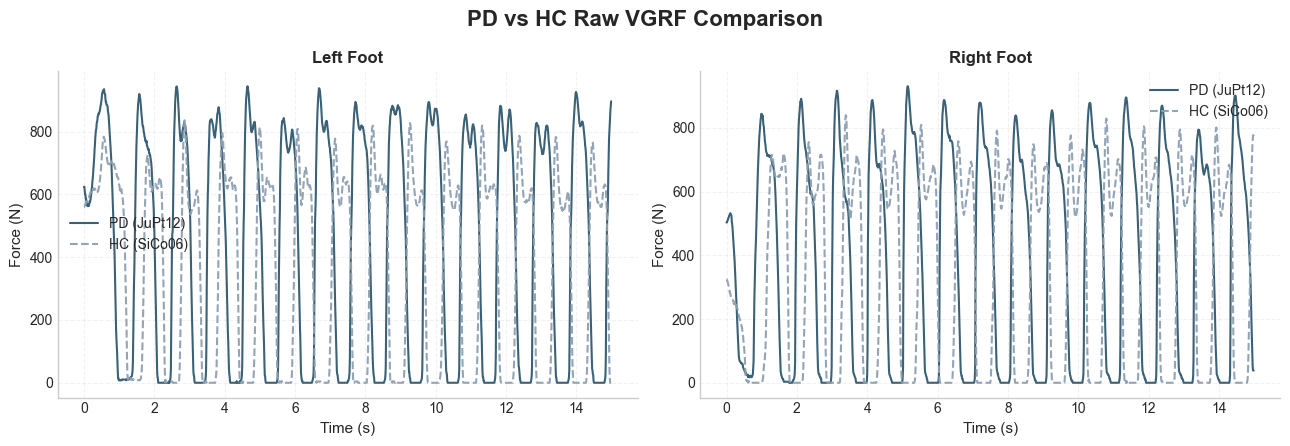

In [ ]:
def plot_overlay_signals(file_df, save=True):

    # --------------------------------------------------
    # Select representative subjects
    # --------------------------------------------------
    pd_subject = (
        file_df[file_df["label"] == "PD"]
        .sample(1, random_state=42)
        .iloc[0]
    )

    hc_subject = (
        file_df[file_df["label"] == "HC"]
        .sample(1, random_state=42)
        .iloc[0]
    )

    SHOW = 15 * SAMPLE_RATE

    pd_sig = load_signal(pd_subject["filepath"])
    hc_sig = load_signal(hc_subject["filepath"])

    # --------------------------------------------------
    # Colors
    # --------------------------------------------------
    PD_COLOR = "#2F586E"
    HC_COLOR = "#8C9FB1"

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 4.5)
    )

    fig.suptitle(
        "PD vs HC Raw VGRF Comparison",
        fontsize=16,
        fontweight="bold"
    )

    for ax, force_col, foot in zip(
        axes,
        [TOTAL_LEFT, TOTAL_RIGHT],
        ["Left Foot", "Right Foot"]
    ):

        t_pd = pd_sig["Time"].values[:SHOW]
        y_pd = pd_sig[force_col].values[:SHOW]

        t_hc = hc_sig["Time"].values[:SHOW]
        y_hc = hc_sig[force_col].values[:SHOW]

        # ----------------------------------------------
        # PD
        # ----------------------------------------------
        ax.plot(
            t_pd,
            y_pd,
            color=PD_COLOR,
            lw=1.5,
            linestyle="-",
            alpha=0.95,
            label=f"PD ({pd_subject['subject_id']})"
        )

        # ----------------------------------------------
        # HC
        # ----------------------------------------------
        ax.plot(
            t_hc,
            y_hc,
            color=HC_COLOR,
            lw=1.5,
            linestyle="--",
            alpha=0.95,
            label=f"HC ({hc_subject['subject_id']})"
        )

        # ----------------------------------------------
        # Axis styling
        # ----------------------------------------------
        ax.set_title(
            foot,
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Time (s)",
            fontsize=11
        )

        ax.set_ylabel(
            "Force (N)",
            fontsize=11
        )

        ax.grid(
            linestyle="--",
            alpha=0.25
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.legend(
            frameon=False,
            fontsize=10
        )

    plt.tight_layout()

    if save:
        plt.savefig(
            f"{OUTPUT_DIR}/fig_overlay_raw_signals.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# Run
plot_overlay_signals(file_df)

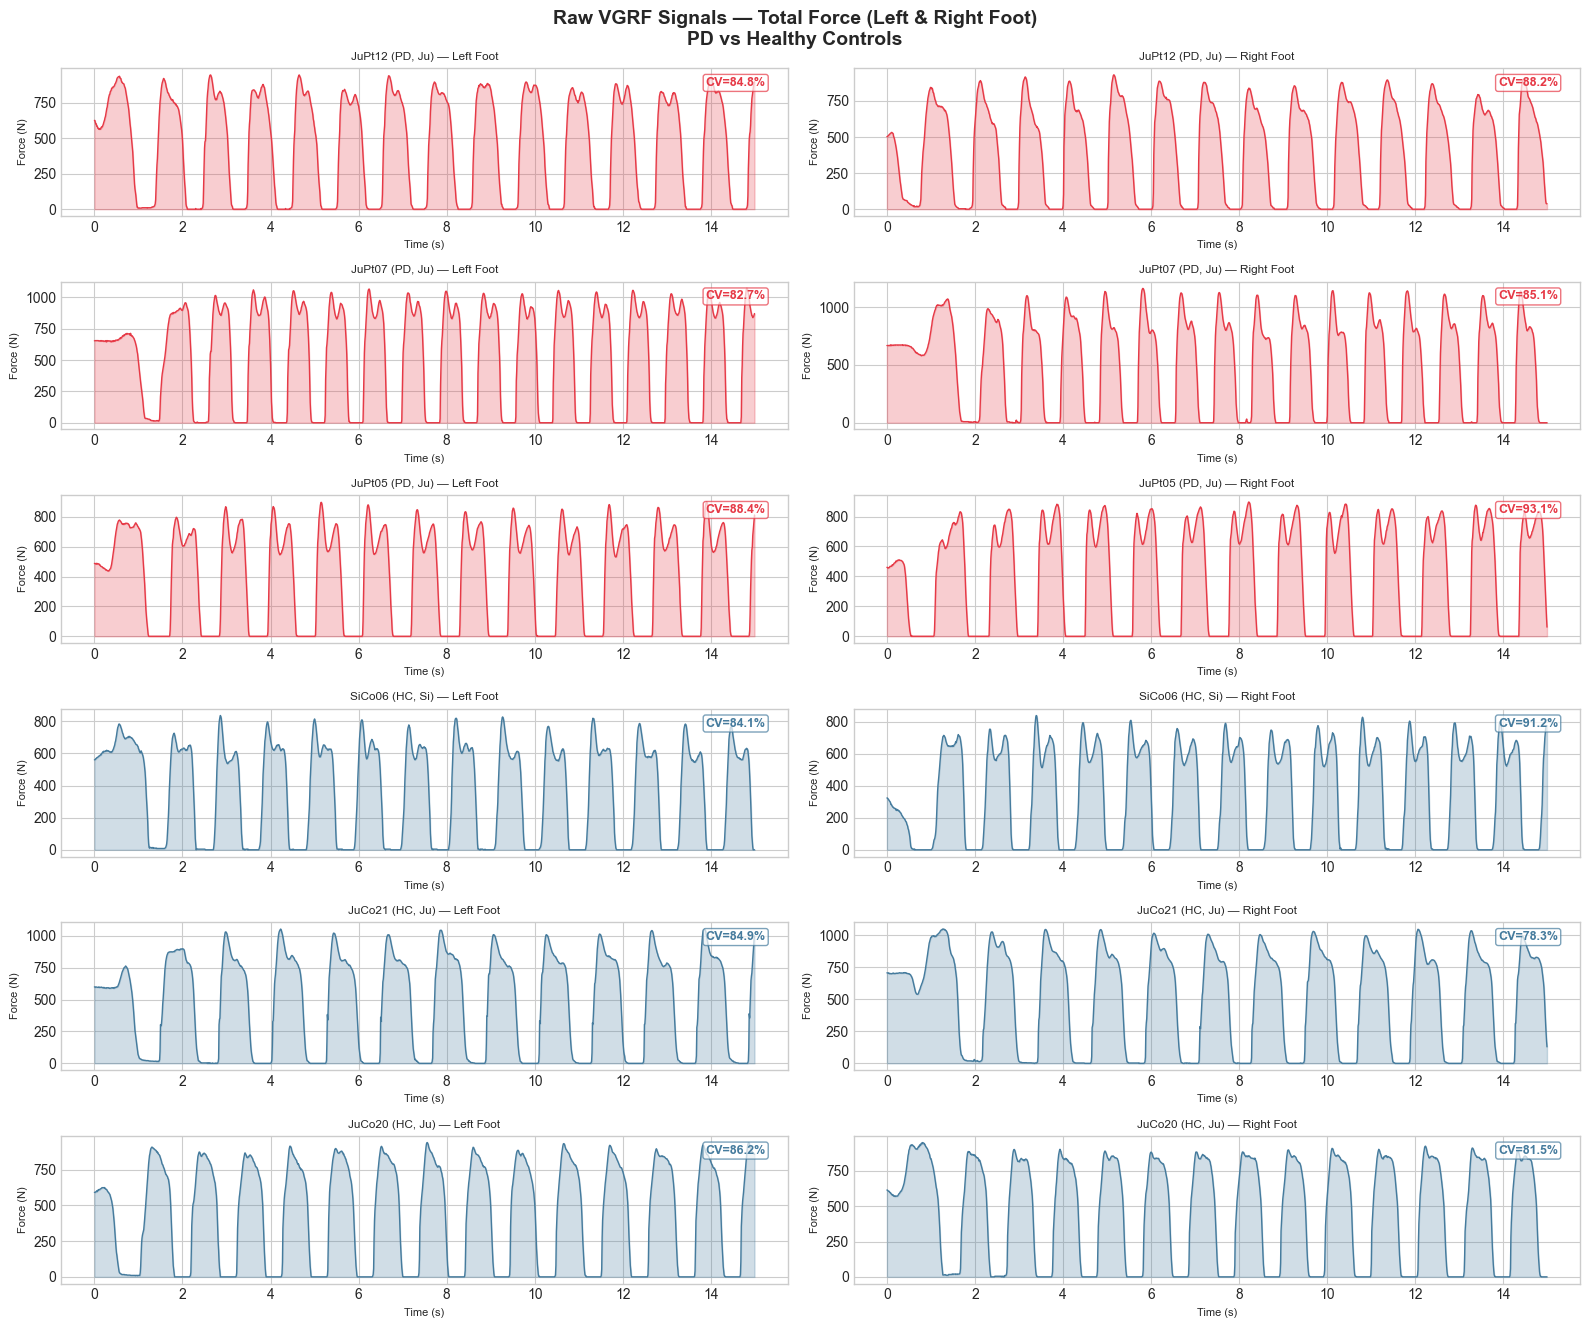

In [5]:
def plot_raw_signals(file_df, n=3, save=True):
    pd_files = file_df[file_df["label"]=="PD"].sample(n=n, random_state=42)
    hc_files = file_df[file_df["label"]=="HC"].sample(n=n, random_state=42)
    all_f    = pd.concat([pd_files, hc_files])
    SHOW     = 15 * SAMPLE_RATE

    fig, axes = plt.subplots(n*2, 2, figsize=(16, n*4.5))
    fig.suptitle("Raw VGRF Signals — Total Force (Left & Right Foot)\nPD vs Healthy Controls",
                 fontsize=14, fontweight="bold")
    for i, (_, row) in enumerate(all_f.iterrows()):
        sig = load_signal(row["filepath"]); color = PALETTE[row["label"]]
        t   = sig["Time"].values[:SHOW]
        for j, (col, foot) in enumerate([(TOTAL_LEFT,"Left Foot"),(TOTAL_RIGHT,"Right Foot")]):
            ax = axes[i, j]; y = sig[col].values[:SHOW]
            ax.fill_between(t, y, alpha=0.25, color=color)
            ax.plot(t, y, color=color, lw=1.0)
            cv = np.std(y)/(np.mean(y)+1e-8)*100
            ax.set_title(f"{row['subject_id']} ({row['label']}, {row['cohort']}) — {foot}", fontsize=8.5)
            ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("Force (N)", fontsize=8)
            ax.text(0.97, 0.88, f"CV={cv:.1f}%", transform=ax.transAxes, ha="right",
                    fontsize=9, color=color, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor=color, alpha=0.7))
    plt.tight_layout()
    if save: plt.savefig(f"{OUTPUT_DIR}/fig_raw_signals.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_raw_signals(file_df, n=3)


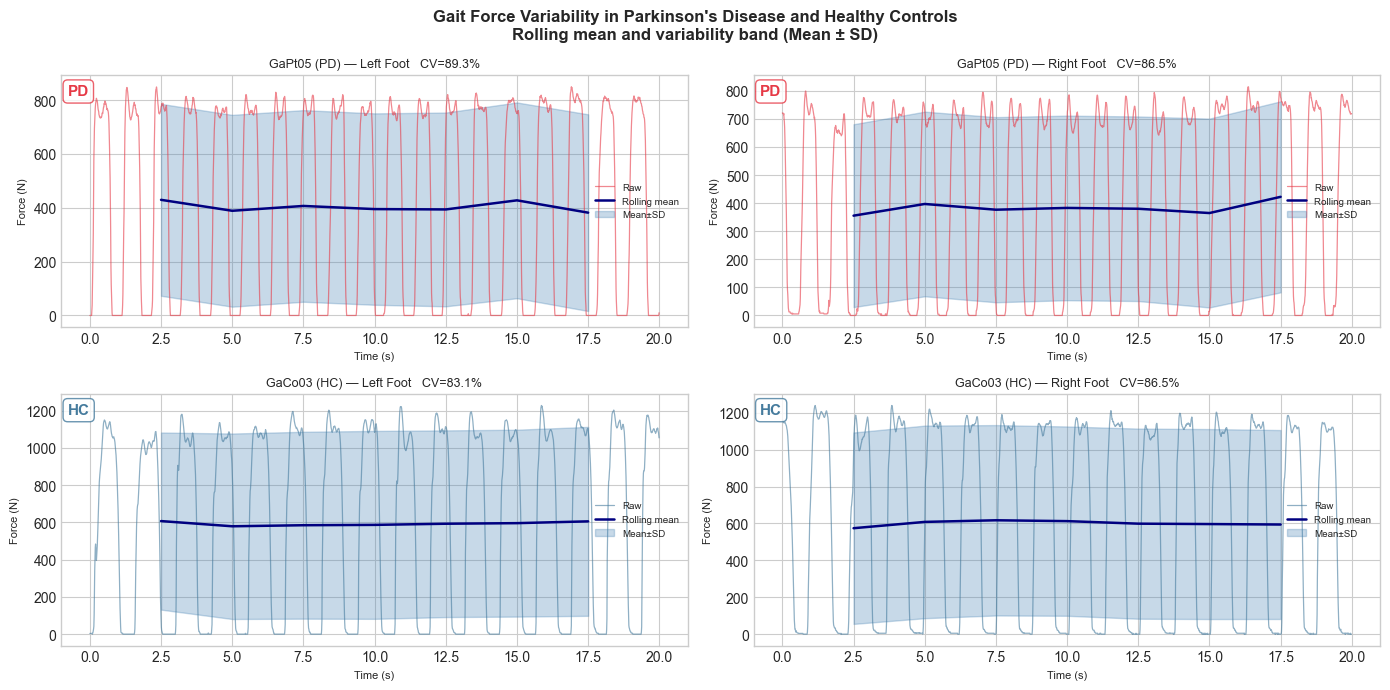

In [14]:
def plot_variability(file_df, save=True):
    pd_row = file_df[file_df["label"]=="PD"].iloc[1]
    hc_row = file_df[file_df["label"]=="HC"].iloc[1]

    # pd_row = pd_df.loc[pd_df["cv_feature"].idxmax()]
    # hc_row = hc_df.loc[hc_df["cv_feature"].idxmedian()]
    SHOW   = 20 * SAMPLE_RATE
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(
        "Gait Force Variability in Parkinson's Disease and Healthy Controls\n"
        "Rolling mean and variability band (Mean ± SD)",
        fontsize=12,
        fontweight="bold"
    )
    for ri, (row, lbl) in enumerate([(pd_row,"PD"), (hc_row,"HC")]):
        sig = load_signal(row["filepath"]); color = PALETTE[lbl]; PLOT = min(len(sig), SHOW)
        t   = sig["Time"].values[:PLOT]
        for ci, (col, foot) in enumerate([(TOTAL_LEFT,"Left Foot"),(TOTAL_RIGHT,"Right Foot")]):
            ax = axes[ri, ci]; y = sig[col].values[:PLOT]
            wins, mns, sds = [], [], []
            for s in range(0, len(y)-WINDOW_SAMPLES+1, STEP_SAMPLES):
                seg = y[s:s+WINDOW_SAMPLES]
                mns.append(np.mean(seg)); sds.append(np.std(seg))
                wins.append(t[s+WINDOW_SAMPLES//2])
            mns, sds, wins = np.array(mns), np.array(sds), np.array(wins)
            ax.plot(t, y, color=color, lw=0.9, alpha=0.6, label="Raw")
            ax.plot(wins, mns, color="navy", lw=1.8, label="Rolling mean")
            ax.fill_between(wins, mns-sds, mns+sds, color="steelblue", alpha=0.30, label="Mean±SD")
            cv = np.std(y)/(np.mean(y)+1e-8)*100
            ax.set_title(f"{row['subject_id']} ({lbl}) — {foot}   CV={cv:.1f}%", fontsize=9)
            ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("Force (N)", fontsize=8)
            ax.legend(fontsize=7); ax.text(0.01, 0.92, lbl, transform=ax.transAxes,
                fontsize=11, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color, alpha=0.8))
    plt.tight_layout()
    if save: plt.savefig(f"{OUTPUT_DIR}/fig_variability.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_variability(file_df)


PD Left cycles  : 4984
HC Left cycles  : 4975
PD Right cycles : 4986
HC Right cycles : 4986


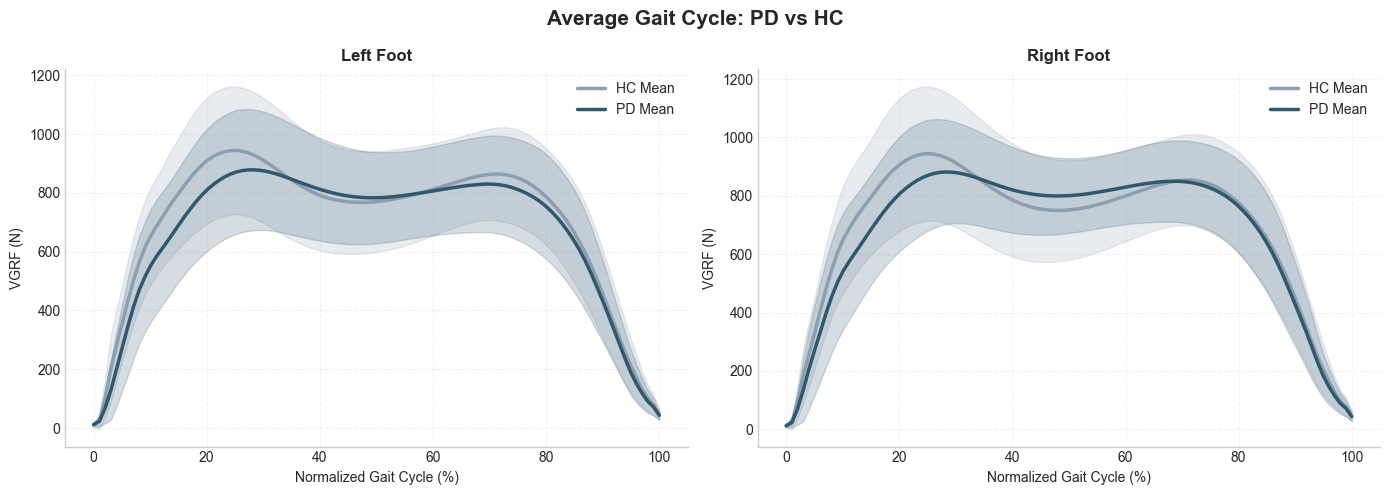

In [16]:


# ==========================================================
# PARAMETERS
# ==========================================================

FORCE_THRESHOLD = 20      # N
CYCLE_LENGTH = 100        # normalize each cycle to 100 points

PD_COLOR = "#2F586E"
HC_COLOR = "#8C9FB1"

# ==========================================================
# EXTRACT STANCE CYCLES
# ==========================================================

def extract_cycles(signal, threshold=FORCE_THRESHOLD):

    above = signal > threshold

    starts = np.where(np.diff(above.astype(int)) == 1)[0]
    ends   = np.where(np.diff(above.astype(int)) == -1)[0]

    if len(starts) == 0 or len(ends) == 0:
        return []

    if ends[0] < starts[0]:
        ends = ends[1:]

    n = min(len(starts), len(ends))

    starts = starts[:n]
    ends   = ends[:n]

    cycles = []

    for s, e in zip(starts, ends):

        cycle = signal[s:e]

        # remove extremely short noisy segments
        if len(cycle) < 30:
            continue

        cycles.append(cycle)

    return cycles


# ==========================================================
# NORMALIZE EACH CYCLE TO 100 POINTS
# ==========================================================

def normalize_cycle(cycle, n_points=CYCLE_LENGTH):

    return resample(cycle, n_points)


# ==========================================================
# COLLECT ALL CYCLES FOR PD / HC
# ==========================================================

def collect_cycles(file_df, force_col):

    pd_cycles = []
    hc_cycles = []

    for _, row in file_df.iterrows():

        try:
            sig = load_signal(row["filepath"])

            y = sig[force_col].values

            cycles = extract_cycles(y)

            for cycle in cycles:

                cycle = normalize_cycle(cycle)

                if row["label"] == "PD":
                    pd_cycles.append(cycle)
                else:
                    hc_cycles.append(cycle)

        except Exception:
            continue

    return np.array(pd_cycles), np.array(hc_cycles)


# ==========================================================
# COMPUTE MEAN ± SD
# ==========================================================

def compute_stats(cycles):

    mean = np.mean(cycles, axis=0)
    std  = np.std(cycles, axis=0)

    return mean, std


# ==========================================================
# MAIN PLOT
# ==========================================================

def plot_mean_gait_cycle(file_df, save=True):

    # ---------------------------
    # LEFT FOOT
    # ---------------------------
    pd_left, hc_left = collect_cycles(
        file_df,
        TOTAL_LEFT
    )

    # ---------------------------
    # RIGHT FOOT
    # ---------------------------
    pd_right, hc_right = collect_cycles(
        file_df,
        TOTAL_RIGHT
    )

    print(f"PD Left cycles  : {len(pd_left)}")
    print(f"HC Left cycles  : {len(hc_left)}")
    print(f"PD Right cycles : {len(pd_right)}")
    print(f"HC Right cycles : {len(hc_right)}")

    # ---------------------------
    # Statistics
    # ---------------------------
    pd_left_mean, pd_left_std = compute_stats(pd_left)
    hc_left_mean, hc_left_std = compute_stats(hc_left)

    pd_right_mean, pd_right_std = compute_stats(pd_right)
    hc_right_mean, hc_right_std = compute_stats(hc_right)

    x = np.linspace(0, 100, CYCLE_LENGTH)

    # ---------------------------
    # Figure
    # ---------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    fig.suptitle(
        "Average Gait Cycle: PD vs HC",
        fontsize=15,
        fontweight="bold"
    )

    # =====================================================
    # LEFT FOOT
    # =====================================================
    ax = axes[0]

    ax.plot(
        x,
        hc_left_mean,
        color=HC_COLOR,
        lw=2.5,
        label="HC Mean"
    )

    ax.fill_between(
        x,
        hc_left_mean - hc_left_std,
        hc_left_mean + hc_left_std,
        color=HC_COLOR,
        alpha=0.20
    )

    ax.plot(
        x,
        pd_left_mean,
        color=PD_COLOR,
        lw=2.5,
        label="PD Mean"
    )

    ax.fill_between(
        x,
        pd_left_mean - pd_left_std,
        pd_left_mean + pd_left_std,
        color=PD_COLOR,
        alpha=0.20
    )

    ax.set_title(
        "Left Foot",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Normalized Gait Cycle (%)"
    )

    ax.set_ylabel(
        "VGRF (N)"
    )

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False)

    # =====================================================
    # RIGHT FOOT
    # =====================================================
    ax = axes[1]

    ax.plot(
        x,
        hc_right_mean,
        color=HC_COLOR,
        lw=2.5,
        label="HC Mean"
    )

    ax.fill_between(
        x,
        hc_right_mean - hc_right_std,
        hc_right_mean + hc_right_std,
        color=HC_COLOR,
        alpha=0.20
    )

    ax.plot(
        x,
        pd_right_mean,
        color=PD_COLOR,
        lw=2.5,
        label="PD Mean"
    )

    ax.fill_between(
        x,
        pd_right_mean - pd_right_std,
        pd_right_mean + pd_right_std,
        color=PD_COLOR,
        alpha=0.20
    )

    ax.set_title(
        "Right Foot",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Normalized Gait Cycle (%)"
    )

    ax.set_ylabel(
        "VGRF (N)"
    )

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False)

    plt.tight_layout()

    if save:
        plt.savefig(
            f"{OUTPUT_DIR}/fig_mean_gait_cycle_bilateral.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ==========================================================
# RUN
# ==========================================================

plot_mean_gait_cycle(file_df)

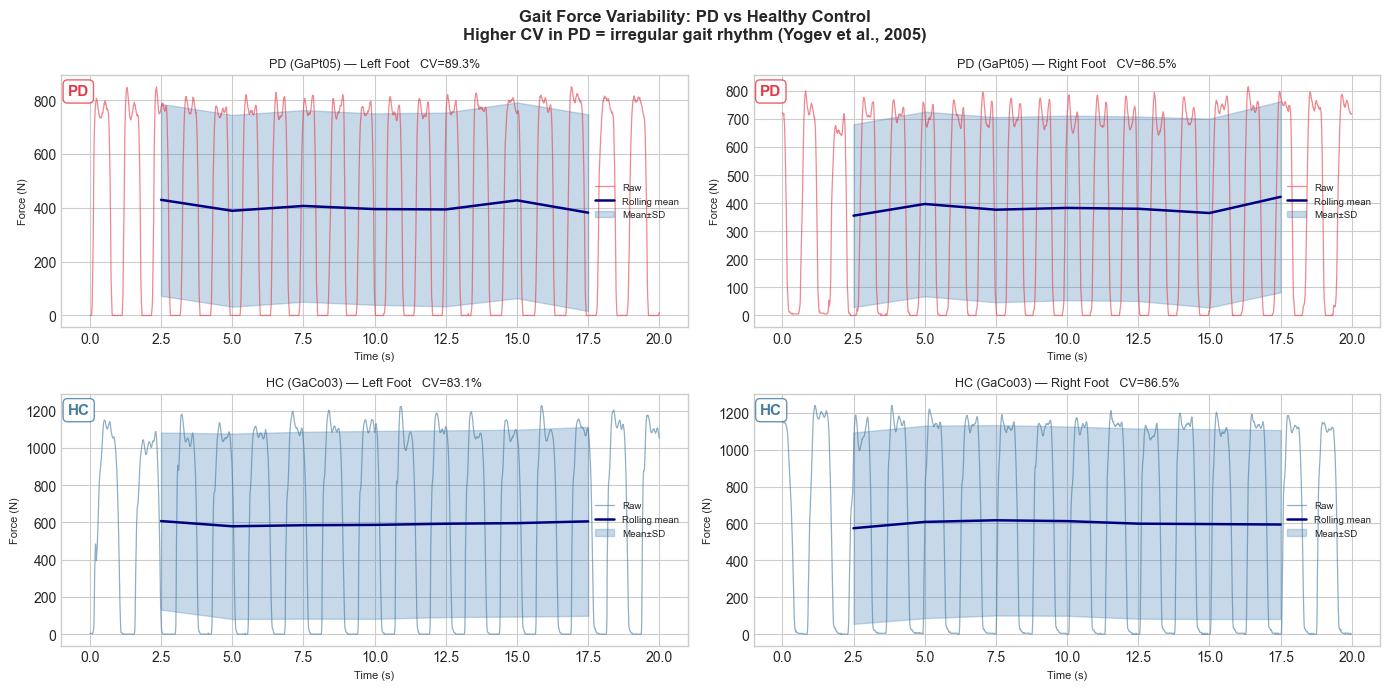

In [ ]:
def plot_variability(file_df, save=True):
    pd_row = file_df[file_df["label"]=="PD"].iloc[1]
    hc_row = file_df[file_df["label"]=="HC"].iloc[1]
    SHOW   = 20 * SAMPLE_RATE
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle("Gait Force Variability: PD vs Healthy Control\n"
                 "Higher CV in PD = irregular gait rhythm (Yogev et al., 2005)",
                 fontsize=12, fontweight="bold")
    for ri, (row, lbl) in enumerate([(pd_row,"PD"), (hc_row,"HC")]):
        sig = load_signal(row["filepath"]); color = PALETTE[lbl]; PLOT = min(len(sig), SHOW)
        t   = sig["Time"].values[:PLOT]
        for ci, (col, foot) in enumerate([(TOTAL_LEFT,"Left Foot"),(TOTAL_RIGHT,"Right Foot")]):
            ax = axes[ri, ci]; y = sig[col].values[:PLOT]
            wins, mns, sds = [], [], []
            for s in range(0, len(y)-WINDOW_SAMPLES+1, STEP_SAMPLES):
                seg = y[s:s+WINDOW_SAMPLES]
                mns.append(np.mean(seg)); sds.append(np.std(seg))
                wins.append(t[s+WINDOW_SAMPLES//2])
            mns, sds, wins = np.array(mns), np.array(sds), np.array(wins)
            ax.plot(t, y, color=color, lw=0.9, alpha=0.6, label="Raw")
            ax.plot(wins, mns, color="navy", lw=1.8, label="Rolling mean")
            ax.fill_between(wins, mns-sds, mns+sds, color="steelblue", alpha=0.30, label="Mean±SD")
            cv = np.std(y)/(np.mean(y)+1e-8)*100
            ax.set_title(f"{lbl} ({row['subject_id']}) — {foot}   CV={cv:.1f}%", fontsize=9)
            ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("Force (N)", fontsize=8)
            ax.legend(fontsize=7); ax.text(0.01, 0.92, lbl, transform=ax.transAxes,
                fontsize=11, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color, alpha=0.8))
    plt.tight_layout()
    if save: plt.savefig(f"{OUTPUT_DIR}/fig_variability.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_variability(file_df)


---
## 4. Feature Extraction

### Approach A — TSFresh (Primary)
TSFresh extracts ~750+ features per channel per window. We then compute **mean, std, skewness, kurtosis** across windows to get one vector per subject.

### Approach B — Manual Features (Alternative, faster)
15 interpretable features per channel: mean, std, min, max, skewness, kurtosis, Q25, Q75, mean|Δ|, std Δ, range, CV, energy, dominant frequency, low-frequency energy.

> **Features are extracted for 3 conditions:** left foot only · right foot only · combined (concatenation)
> **Z-score normalisation** is applied to the feature matrix before PCA/t-SNE.


In [58]:
# ── Option A: TSFresh ─────────────────────────────────────────────────────
# IMPORTANT: TSFresh is slow (~7-10 min for 80 subjects).
# Run this cell to use TSFresh features (recommended for final submission).
# Skip to Option B for fast testing.

RUN_TSFRESH = True  # ← Set to True to run TSFresh

if RUN_TSFRESH:
    from tsfresh import extract_features
    from tsfresh.utilities.dataframe_functions import impute
    from tsfresh.feature_extraction import MinimalFCParameters, EfficientFCParameters, ComprehensiveFCParameters

    def build_window_df(sig, sid, feat_cols):
        y = sig[feat_cols].values
        rows, wid = [], 0
        for start in range(0, len(y)-WINDOW_SAMPLES+1, STEP_SAMPLES):
            seg = y[start:start+WINDOW_SAMPLES]
            for ti in range(WINDOW_SAMPLES):
                r = {"window_id": f"{sid}_w{wid}", "time": ti}
                for ci, c in enumerate(feat_cols): r[c] = seg[ti, ci]
                rows.append(r)
            wid += 1
        return pd.DataFrame(rows), wid

    def extract_tsfresh(file_df, foot="left"):
        cols_map = {
            "left":     LEFT_COLS + [TOTAL_LEFT],
            "right":    RIGHT_COLS + [TOTAL_RIGHT],
            "combined": LEFT_COLS + RIGHT_COLS + [TOTAL_LEFT, TOTAL_RIGHT],
        }
        fcols = cols_map[foot]
        print(f"  Extracting TSFresh features — {foot} foot ...")
        wins, meta = [], []
        for _, row in file_df.iterrows():
            if row["fileType"] == "training":
                sig = load_signal(row["filepath"])
                wdf, nw = build_window_df(sig, row["subject_id"], fcols)
                wins.append(wdf)
                for wi in range(nw):
                    meta.append({"window_id": f"{row['subject_id']}_w{wi}",
                                "subject_id": row["subject_id"],
                                "label": row["label"], "cohort": row["cohort"]})
        wins_df = pd.concat(wins, ignore_index=True)
        meta_df = pd.DataFrame(meta)
        features = extract_features(wins_df, column_id="window_id", column_sort="time",
                                    default_fc_parameters=EfficientFCParameters(),
                                    n_jobs=4, show_warnings=False, disable_progressbar=False)
        impute(features)
        print(f"  → {features.shape[0]} windows × {features.shape[1]} features")
        return features, meta_df

    def per_subject_stats(features, meta_df):
        feat_reset = features.reset_index().rename(columns={"index":"window_id"})
        merged = feat_reset.merge(meta_df, on="window_id")
        fcols  = [c for c in features.columns]
        grp    = merged.groupby("subject_id")
        sf = pd.concat([
            grp[fcols].mean().add_suffix("__mean"),
            grp[fcols].std().add_suffix("__std"),
            grp[fcols].apply(lambda x: x.apply(sp_stats.skew)).add_suffix("__skew"),
            grp[fcols].apply(lambda x: x.apply(sp_stats.kurtosis)).add_suffix("__kurt"),
        ], axis=1).fillna(0)
        lmap = meta_df.drop_duplicates("subject_id").set_index("subject_id")[["label","cohort"]]
        return sf.join(lmap)

    left_sf   = per_subject_stats(*extract_tsfresh(file_df, "left"))
    right_sf  = per_subject_stats(*extract_tsfresh(file_df, "right"))
    comb_sf   = per_subject_stats(*extract_tsfresh(file_df, "combined"))
    print(f"\nTSFresh shapes: left={left_sf.shape}, right={right_sf.shape}, combined={comb_sf.shape}")
    FEATURE_METHOD = "TSFresh"
else:
    print("TSFresh skipped (RUN_TSFRESH=False). Running Option B (manual features)...")


  Extracting TSFresh features — left foot ...


Feature Extraction: 100%|██████████| 20/20 [04:36<00:00, 13.85s/it]


  → 2579 windows × 6993 features
  Extracting TSFresh features — right foot ...


Feature Extraction: 100%|██████████| 20/20 [07:19<00:00, 21.95s/it]


  → 2579 windows × 6993 features
  Extracting TSFresh features — combined foot ...


Feature Extraction: 100%|██████████| 20/20 [13:10<00:00, 39.51s/it]


  → 2579 windows × 13986 features

TSFresh shapes: left=(60, 27974), right=(60, 27974), combined=(60, 55946)


In [56]:
feature_extraction_left_summary = pd.DataFrame(
    left_sf
)
feature_extraction_left_summary.to_csv(f"{OUTPUT_DIR}/feature_extraction_left_summary.csv", index=False)
feature_extraction_right_summary = pd.DataFrame(
    right_sf
)
feature_extraction_right_summary.to_csv(f"{OUTPUT_DIR}/feature_extraction_right_summary.csv", index=False)
feature_extraction_combined_summary = pd.DataFrame(
    comb_sf
)
feature_extraction_combined_summary.to_csv(f"{OUTPUT_DIR}/feature_extraction_combined_summary.csv", index=False)

In [ ]:
# ── Option B: Manual Features (fast, ~20 seconds) ────────────────────────

# def manual_features_subject(sig, cols):
#     """Extract 15 features per channel per 5s window, then summarise per subject."""
#     y_all = sig[cols].values
#     win_feats = []
#     for start in range(0, len(y_all)-WINDOW_SAMPLES+1, STEP_SAMPLES):
#         seg = y_all[start:start+WINDOW_SAMPLES]
#         wf  = []
#         for ci in range(seg.shape[1]):
#             x    = seg[:, ci]
#             diff = np.diff(x)
#             fft  = np.abs(np.fft.rfft(x))
#             wf  += [
#                 np.mean(x), np.std(x), np.min(x), np.max(x),
#                 float(sp_stats.skew(x)), float(sp_stats.kurtosis(x)),
#                 np.percentile(x, 25), np.percentile(x, 75),
#                 np.mean(np.abs(diff)), np.std(diff),
#                 np.max(x) - np.min(x),
#                 np.std(x) / (np.mean(np.abs(x)) + 1e-9),
#                 np.sum(x**2) / len(x),
#                 float(np.argmax(fft[:50])),
#                 float(np.mean(fft[:10])),
#             ]
#         win_feats.append(wf)

#     if len(win_feats) == 0:
#         return np.zeros(len(cols) * 15 * 4)

#     win_arr = np.array(win_feats)
#     # Per-subject: mean, std, skewness, kurtosis across windows
#     return np.concatenate([
#         win_arr.mean(0),
#         win_arr.std(0),
#         sp_stats.skew(win_arr, axis=0),
#         sp_stats.kurtosis(win_arr, axis=0)
#     ])

# FOOT_COLS = {
#     "left":     LEFT_COLS + [TOTAL_LEFT],
#     "right":    RIGHT_COLS + [TOTAL_RIGHT],
#     "combined": LEFT_COLS + RIGHT_COLS + [TOTAL_LEFT, TOTAL_RIGHT],
# }

# print("Extracting manual features for all subjects...")
# records = []
# for i, (_, row) in enumerate(file_df.iterrows()):
#     sig = load_signal(row["filepath"])
#     for foot, cols in FOOT_COLS.items():
#         f = manual_features_subject(sig, cols)
#         records.append({"subject_id": row["subject_id"], "label": row["label"],
#                         "cohort": row["cohort"], "foot": foot, "features": f})
#     if (i+1) % 20 == 0:
#         print(f"  {i+1}/{len(file_df)} done")

# records_df = pd.DataFrame(records)
# hy_map = fold_merged.drop_duplicates("subject_id").set_index("subject_id")["HoehnYahr"]
# records_df["HoehnYahr"] = records_df["subject_id"].map(hy_map)

# def get_subject_features(foot_name):
#     sub = records_df[records_df["foot"] == foot_name].copy()
#     feat_mat = np.vstack(sub["features"].values)
#     df = pd.DataFrame(feat_mat, index=sub["subject_id"].values)
#     df["label"]     = sub["label"].values
#     df["cohort"]    = sub["cohort"].values
#     df["HoehnYahr"] = sub["HoehnYahr"].values
#     return df

# left_sf   = get_subject_features("left")
# right_sf  = get_subject_features("right")
# comb_sf   = get_subject_features("combined")
# FEATURE_METHOD = "Manual (15 features/channel)"

# print(f"\n✅ Feature extraction complete using: {FEATURE_METHOD}")
# print(f"Shapes: left={left_sf.shape}, right={right_sf.shape}, combined={comb_sf.shape}")


Extracting manual features for all subjects...
  20/80 done
  40/80 done
  60/80 done
  80/80 done

✅ Feature extraction complete using: Manual (15 features/channel)
Shapes: left=(80, 543), right=(80, 543), combined=(80, 1083)


In [59]:
# ── Summary statistics per subject per feature set ─────────────────────────
META = {"label", "cohort", "HoehnYahr"}

print(f"Feature Statistics Summary  [{FEATURE_METHOD}]")
print("="*55)
for name, sf in [("Left foot", left_sf), ("Right foot", right_sf), ("Combined", comb_sf)]:
    fcols = [c for c in sf.columns if c not in META]
    pd_v  = sf[sf["label"]=="PD"][fcols].values.flatten()
    hc_v  = sf[sf["label"]=="HC"][fcols].values.flatten()
    print(f"\n  {name}  ({len(fcols)} features)")
    print(f"  PD — mean: {pd_v.mean():.4f} | std: {pd_v.std():.4f} | "
          f"skew: {sp_stats.skew(pd_v):.3f} | kurt: {sp_stats.kurtosis(pd_v):.3f}")
    print(f"  HC — mean: {hc_v.mean():.4f} | std: {hc_v.std():.4f} | "
          f"skew: {sp_stats.skew(hc_v):.3f} | kurt: {sp_stats.kurtosis(hc_v):.3f}")


Feature Statistics Summary  [TSFresh]

  Left foot  (27972 features)
  PD — mean: 43971.9685 | std: 3594382.5087 | skew: 127.087 | kurt: 19652.474
  HC — mean: 56134.8682 | std: 4582862.0357 | skew: 132.490 | kurt: 22025.695

  Right foot  (27972 features)
  PD — mean: 45266.6706 | std: 3559149.0284 | skew: 116.824 | kurt: 16648.434
  HC — mean: 54621.3642 | std: 4522192.2288 | skew: 141.647 | kurt: 26360.069

  Combined  (55944 features)
  PD — mean: 44619.3196 | std: 3576809.2110 | skew: 122.036 | kurt: 18181.800
  HC — mean: 55378.1162 | std: 4552628.2595 | skew: 136.986 | kurt: 24139.417


---
## 5. PCA — Principal Component Analysis

**Z-score normalisation applied before PCA.** Three panels per plot:
- **(A)** Coloured by diagnosis (PD/HC)
- **(B)** Coloured by cohort — checks for cohort confound
- **(C)** Coloured by H&Y severity stage (PD only)


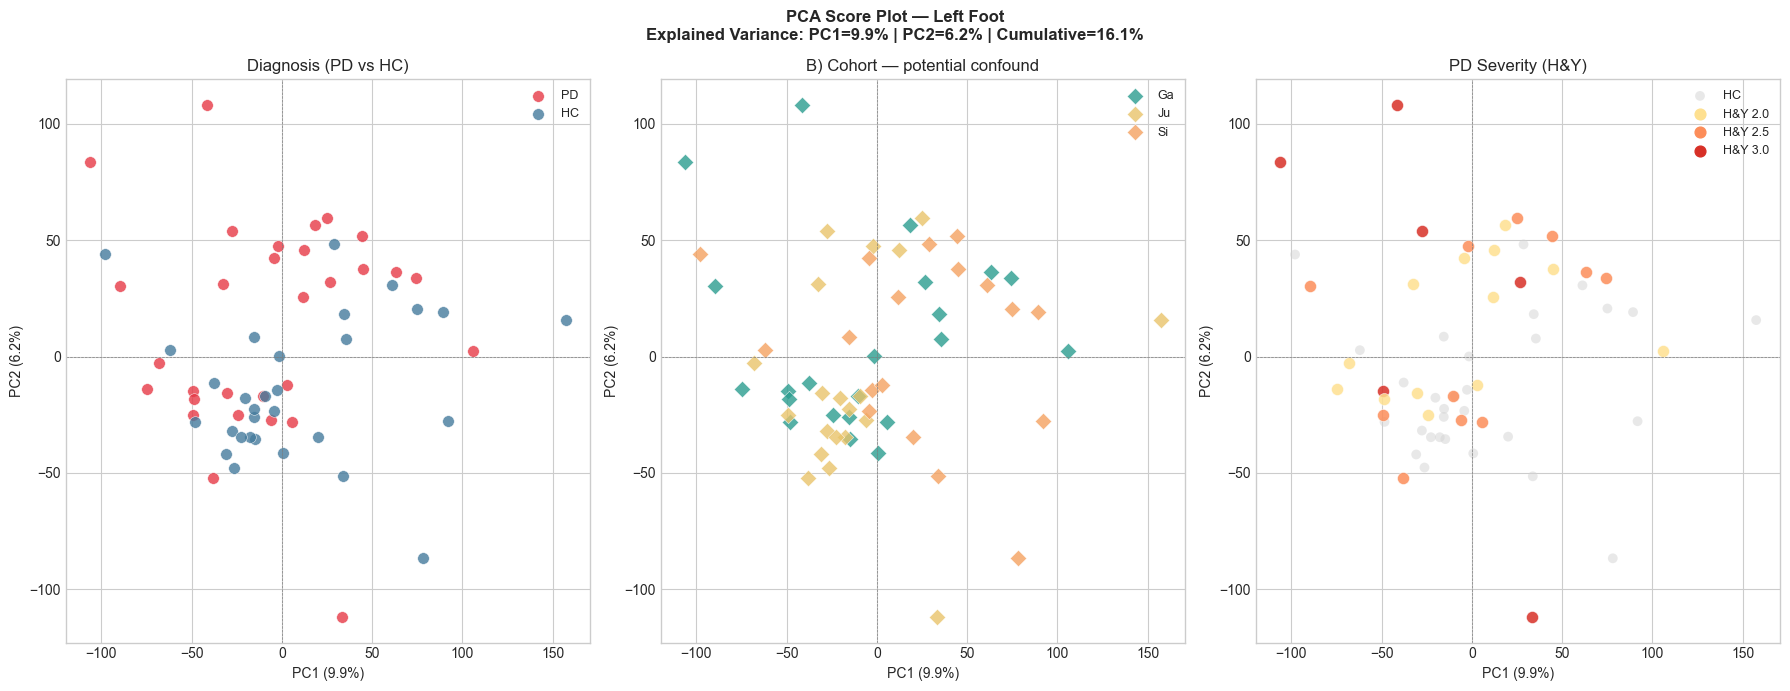


Top 5 PC1 loadings (Left Foot):
  L2__fft_coefficient__attr_"imag"__coeff_63__std             
  L2__fft_coefficient__attr_"abs"__coeff_63__mean             
  L3__fft_coefficient__attr_"abs"__coeff_96__mean             
  L3__change_quantiles__f_agg_"mean"__isabs_False__qh_0.8__ql_
  L3__fft_coefficient__attr_"abs"__coeff_41__std              


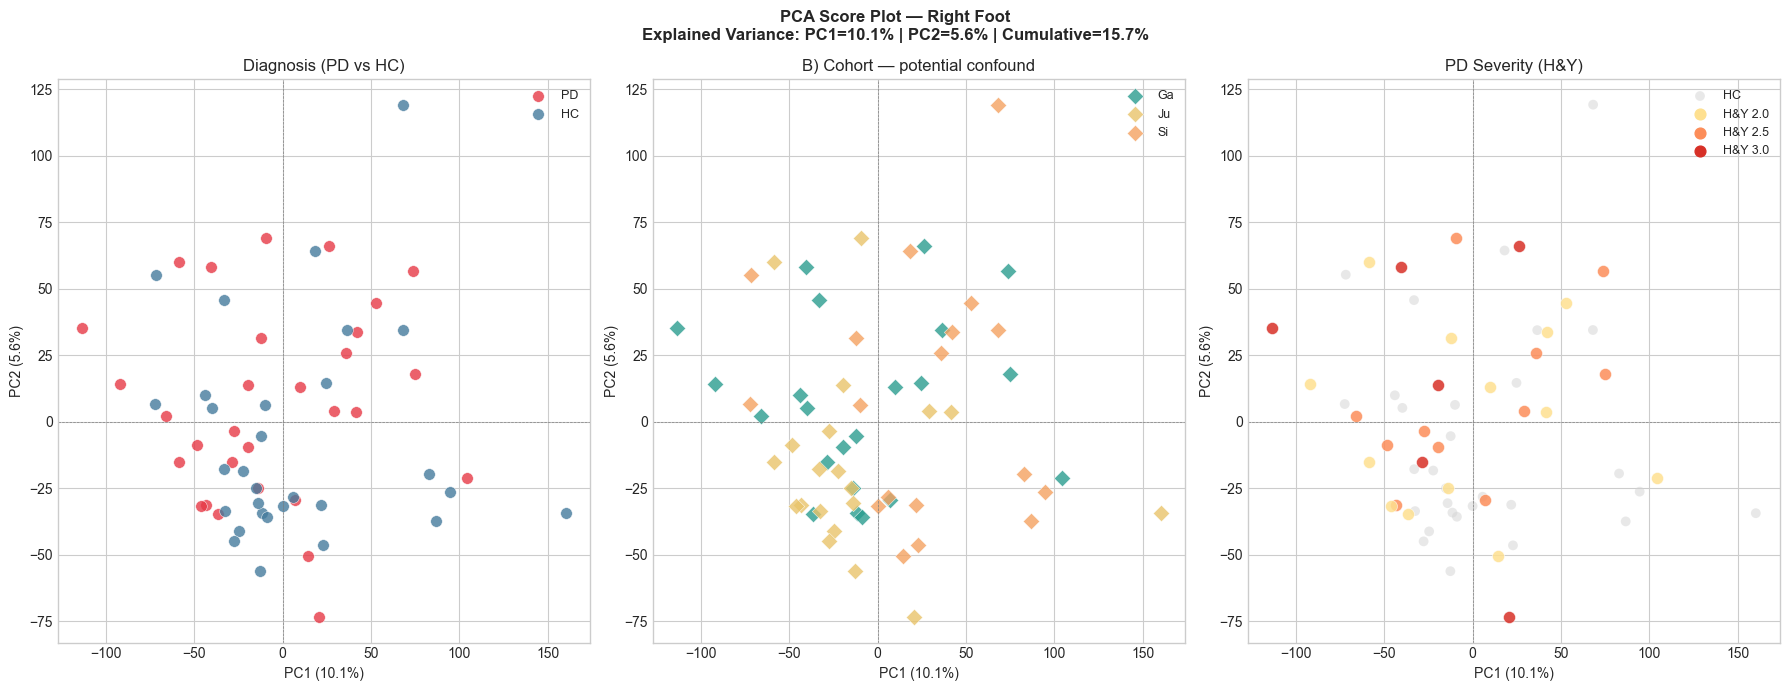


Top 5 PC1 loadings (Right Foot):
  R3__fft_coefficient__attr_"imag"__coeff_92__std             
  R3__fft_coefficient__attr_"imag"__coeff_98__std             
  R3__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_
  R3__fft_coefficient__attr_"abs"__coeff_92__mean             
  R3__fft_coefficient__attr_"abs"__coeff_87__mean             


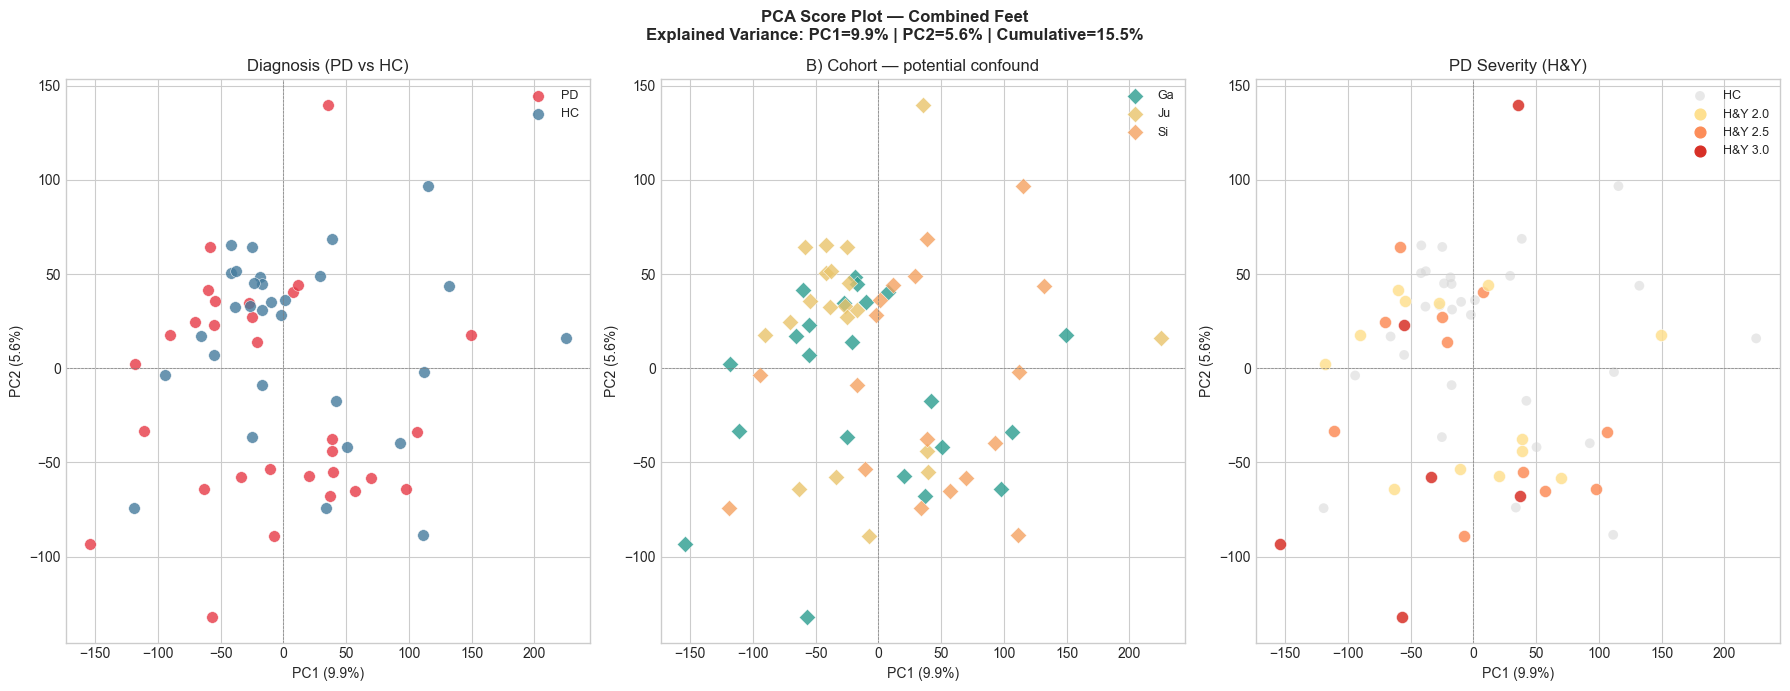


Top 5 PC1 loadings (Combined Feet):
  R3__fft_coefficient__attr_"imag"__coeff_92__std             
  R3__fft_coefficient__attr_"imag"__coeff_98__std             
  R3__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_
  R3__fft_coefficient__attr_"abs"__coeff_98__std              
  R3__fft_coefficient__attr_"abs"__coeff_87__mean             


In [60]:
def plot_pca(sf, foot_label, demo_merged=None, save=True):
    fcols  = [c for c in sf.columns if c not in META]
    X      = SimpleImputer(strategy="median").fit_transform(sf[fcols].values.astype(float))
    X_z    = StandardScaler().fit_transform(X)   # ← Z-SCORE NORMALISATION
    labels = sf["label"].values
    cohs   = sf["cohort"].values

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_z)
    ev     = pca.explained_variance_ratio_

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f"PCA Score Plot — {foot_label}\n"
                f"Explained Variance: PC1={ev[0]*100:.1f}% | "
                f"PC2={ev[1]*100:.1f}% | "
                f"Cumulative={(ev[0]+ev[1])*100:.1f}%"
                , fontsize=12, fontweight="bold")

    # A — Diagnosis
    ax = axes[0]
    for lbl, col in PALETTE.items():
        m = labels == lbl
        ax.scatter(coords[m,0], coords[m,1], c=col, label=lbl, alpha=0.8,
                   s=70, edgecolors="white", lw=0.4)
    ax.set_title("Diagnosis (PD vs HC)"); ax.legend(fontsize=9)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    ax.axhline(0, c="grey", lw=0.5, ls="--"); ax.axvline(0, c="grey", lw=0.5, ls="--")

    # B — Cohort
    ax = axes[1]
    for coh, col in COHORT_PAL.items():
        m = cohs == coh
        ax.scatter(coords[m,0], coords[m,1], c=col, label=coh, alpha=0.8,
                   s=70, edgecolors="white", lw=0.4, marker="D")
    ax.set_title("B) Cohort — potential confound"); ax.legend(fontsize=9)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    ax.axhline(0, c="grey", lw=0.5, ls="--"); ax.axvline(0, c="grey", lw=0.5, ls="--")

    # C — H&Y
    ax = axes[2]
    ax.scatter(coords[labels=="HC",0], coords[labels=="HC",1],
               c="lightgrey", s=50, alpha=0.5, label="HC", edgecolors="none")
    if demo_merged is not None:
        hy_lkp = demo_merged.drop_duplicates("subject_id").set_index("subject_id")["HoehnYahr"]
        for i, sid in enumerate(sf.index):
            if labels[i] != "PD": continue
            hy = hy_lkp.get(sid, np.nan)
            if np.isnan(hy): continue
            ax.scatter(coords[i,0], coords[i,1], c=HY_PAL.get(hy,"black"),
                       s=75, alpha=0.85, edgecolors="white", lw=0.4)
        for hy_v, col in HY_PAL.items():
            ax.scatter([], [], c=col, s=60, label=f"H&Y {hy_v}")
    ax.set_title("PD Severity (H&Y)"); ax.legend(fontsize=9)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    ax.axhline(0, c="grey", lw=0.5, ls="--"); ax.axvline(0, c="grey", lw=0.5, ls="--")

    plt.tight_layout()
    tag = foot_label.lower().replace(" ","_")
    if save: plt.savefig(f"{OUTPUT_DIR}/fig_pca_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top PC1 loadings
    fcols_arr = [c for c in sf.columns if c not in META]
    loads = pd.Series(np.abs(pca.components_[0]), index=fcols_arr)
    print(f"\nTop 5 PC1 loadings ({foot_label}):")
    for f, v in loads.nlargest(5).items():
        print(f"  {str(f)[:60]:<60}")

# Plot all three
training_data = fold_merged[fold_merged["fileType"] == "training"]
plot_pca(left_sf,  "Left Foot",  training_data)
plot_pca(right_sf, "Right Foot", training_data)
plot_pca(comb_sf,  "Combined Feet", training_data)



---
## 6. t-SNE Embedding

**Z-score normalisation applied before t-SNE.** PCA pre-compression (50 components) is applied first for speed and noise reduction.

Two panels per plot: (A) PD/HC diagnosis · (B) Cohort


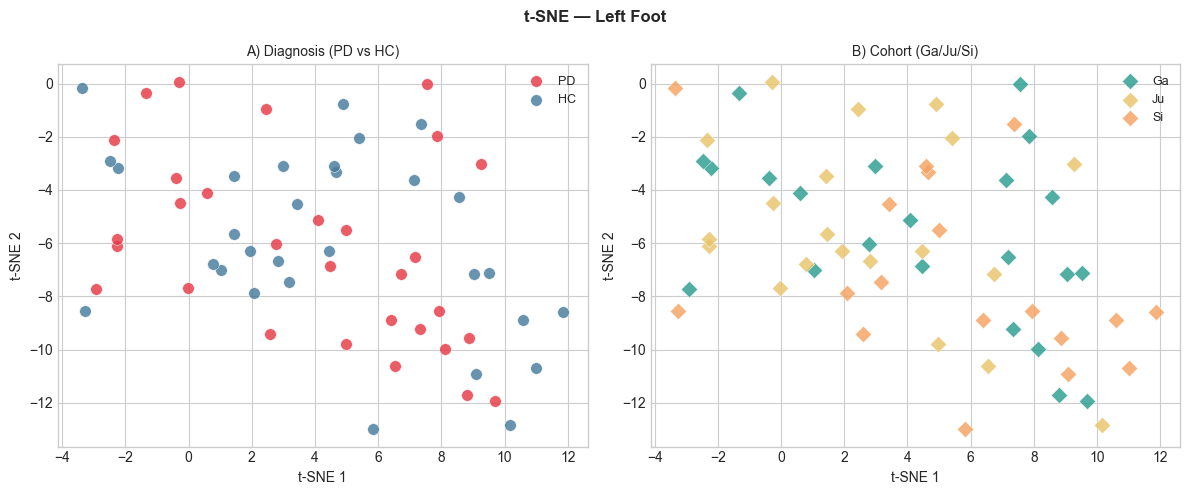

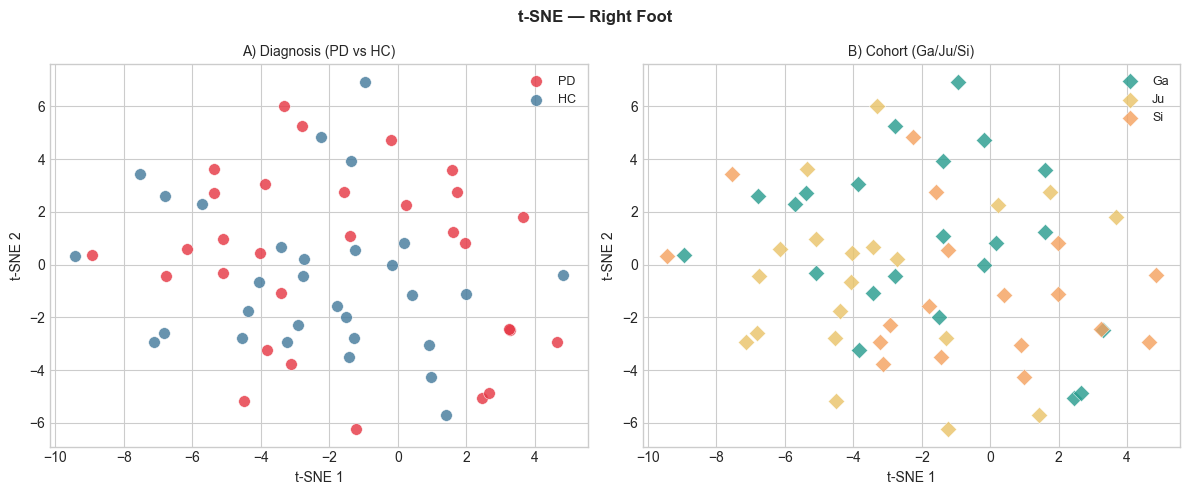

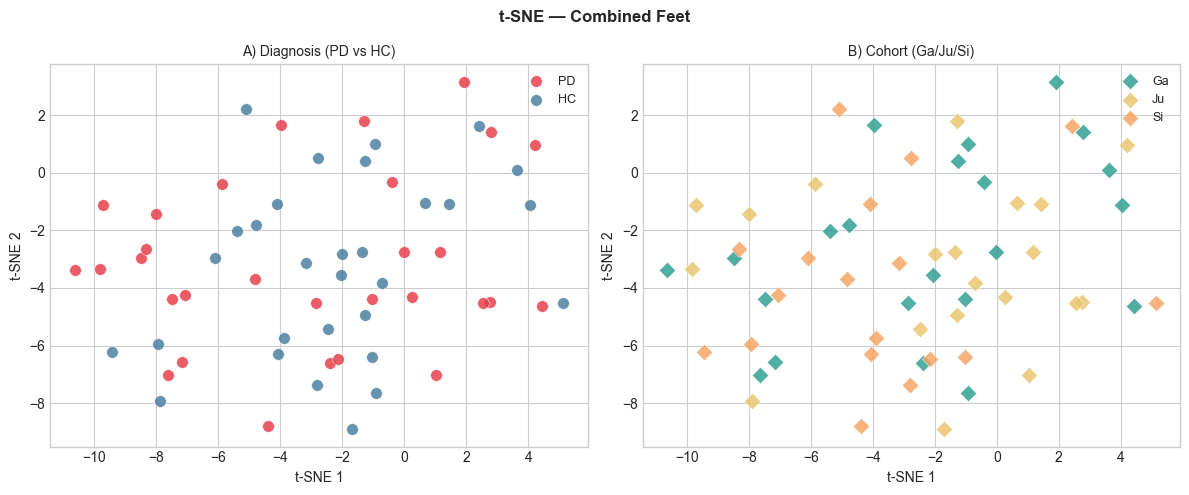

In [22]:
import sklearn
_sv = tuple(int(x) for x in sklearn.__version__.split(".")[:2])

def plot_tsne(sf, foot_label, save=True):
    fcols  = [c for c in sf.columns if c not in META]
    X      = SimpleImputer(strategy="median").fit_transform(sf[fcols].values.astype(float))
    X_z    = StandardScaler().fit_transform(X)   # ← Z-SCORE NORMALISATION
    labels = sf["label"].values; cohs = sf["cohort"].values

    # PCA pre-compression → t-SNE
    n_pca  = min(20, X_z.shape[1], X_z.shape[0]-1)
    X_pca  = PCA(n_components=n_pca, random_state=42).fit_transform(X_z)
    perp   = min(20, max(5, len(labels)//4))
    kw     = dict(n_components=2, random_state=42, perplexity=perp,
                  learning_rate="auto", init="pca")
    kw["max_iter" if _sv>=(1,5) else "n_iter"] = 1000
    coords = TSNE(**kw).fit_transform(X_pca)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"t-SNE — {foot_label}",
                 fontsize=12, fontweight="bold")
    for ax, (title, colorby, pal, marker) in zip(axes, [
        ("A) Diagnosis (PD vs HC)", labels, PALETTE, "o"),
        ("B) Cohort (Ga/Ju/Si)",    cohs,   COHORT_PAL, "D"),
    ]):
        for k, col in pal.items():
            m = colorby == k
            ax.scatter(coords[m,0], coords[m,1], c=col, label=k, alpha=0.82,
                       s=70, edgecolors="white", lw=0.4, marker=marker)
        ax.set_title(title, fontsize=10); ax.legend(fontsize=9)
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    tag = foot_label.lower().replace(" ","_")
    if save: plt.savefig(f"{OUTPUT_DIR}/fig_tsne_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_tsne(left_sf,  "Left Foot")
plot_tsne(right_sf, "Right Foot")
plot_tsne(comb_sf,  "Combined Feet")


---
## 7. Alternative Approaches

Three additional analyses beyond the required PCA/t-SNE:

1. **UMAP** — preserves global structure better than t-SNE  
2. **Mann-Whitney U statistical test** — identify most discriminative features  
3. **Feature heatmap + KDE distributions** — visualise group differences


In [24]:
pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]
Note: you may need to restart the kernel to use updated packages.


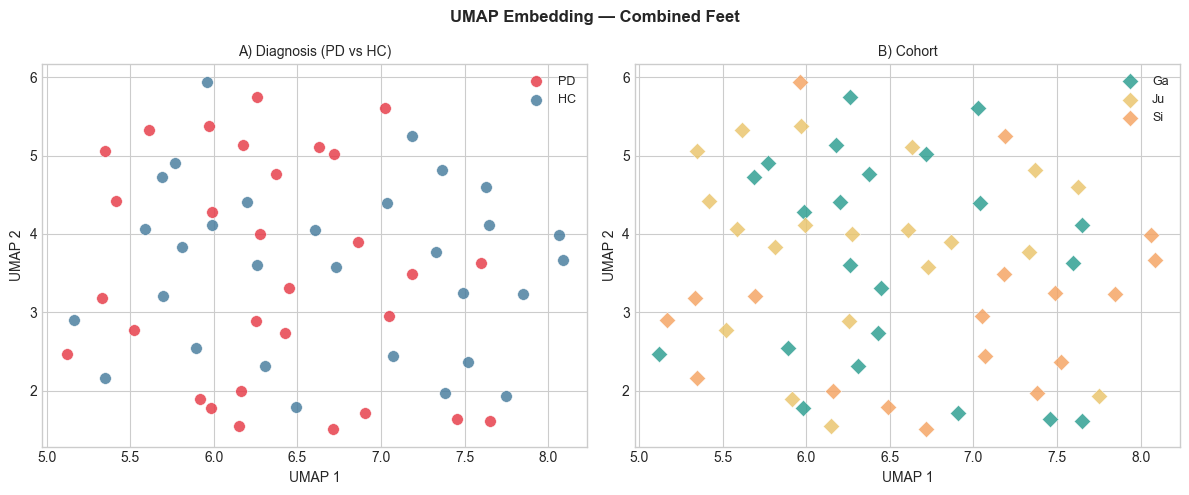

UMAP complete ✅


In [26]:
# ── 7A. UMAP ──────────────────────────────────────────────────────────────
try:
    import umap
    fcols  = [c for c in comb_sf.columns if c not in META]
    X      = SimpleImputer(strategy="median").fit_transform(comb_sf[fcols].values.astype(float))
    X_z    = StandardScaler().fit_transform(X)   # ← Z-SCORE NORMALISATION
    labels = comb_sf["label"].values; cohs = comb_sf["cohort"].values

    reducer = umap.UMAP(n_components=2, random_state=42,
                        n_neighbors=min(15, len(labels)-1), min_dist=0.1)
    coords  = reducer.fit_transform(X_z)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("UMAP Embedding — Combined Feet",
                 fontsize=12, fontweight="bold")
    for ax, (title, colorby, pal, marker) in zip(axes, [
        ("A) Diagnosis (PD vs HC)", labels, PALETTE, "o"),
        ("B) Cohort",               cohs,   COHORT_PAL, "D"),
    ]):
        for k, col in pal.items():
            m = colorby == k
            ax.scatter(coords[m,0], coords[m,1], c=col, label=k, alpha=0.82,
                       s=70, edgecolors="white", lw=0.4, marker=marker)
        ax.set_title(title, fontsize=10); ax.legend(fontsize=9)
        ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_umap_combined.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("UMAP complete ✅")
except ImportError:
    print("umap-learn not installed — run: pip install umap-learn")


Significant features (p<0.05): 5886/55944
Significant features (p<0.001): 731/55944


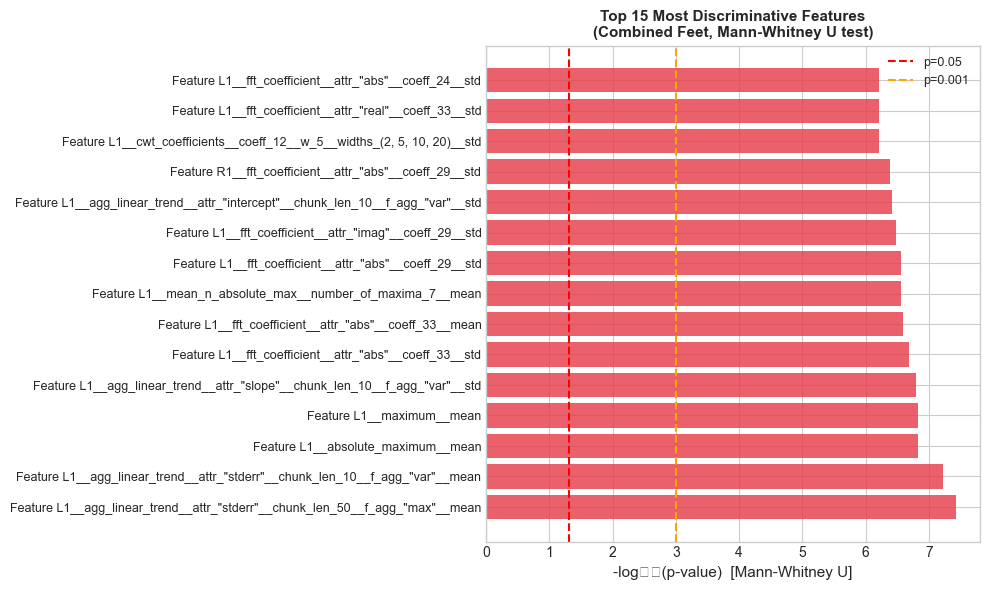

In [27]:
# ── 7B. Mann-Whitney U Feature Significance ──────────────────────────────
fcols = [c for c in comb_sf.columns if c not in META]
pvals = []
for c in fcols:
    a = comb_sf[comb_sf["label"]=="PD"][c].dropna()
    b = comb_sf[comb_sf["label"]=="HC"][c].dropna()
    _, p = mannwhitneyu(a, b, alternative="two-sided") if len(a)>1 and len(b)>1 else (0, 1.0)
    pvals.append(p)

pval_ser = pd.Series(pvals, index=fcols).sort_values()
top15    = pval_ser.head(15)

print(f"Significant features (p<0.05): {(pval_ser<0.05).sum()}/{len(pval_ser)}")
print(f"Significant features (p<0.001): {(pval_ser<0.001).sum()}/{len(pval_ser)}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E63946" if p<0.001 else "#457B9D" if p<0.05 else "grey" for p in top15.values]
ax.barh(range(len(top15)), -np.log10(top15.values+1e-10), color=colors, alpha=0.8)
ax.axvline(-np.log10(0.05),  color="red",    ls="--", lw=1.5, label="p=0.05")
ax.axvline(-np.log10(0.001), color="orange", ls="--", lw=1.5, label="p=0.001")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"Feature {n}" for n in top15.index], fontsize=9)
ax.set_xlabel("-log₁₀(p-value)  [Mann-Whitney U]", fontsize=11)
ax.set_title("Top 15 Most Discriminative Features\n(Combined Feet, Mann-Whitney U test)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig_significance.png", dpi=150, bbox_inches="tight")
plt.show()


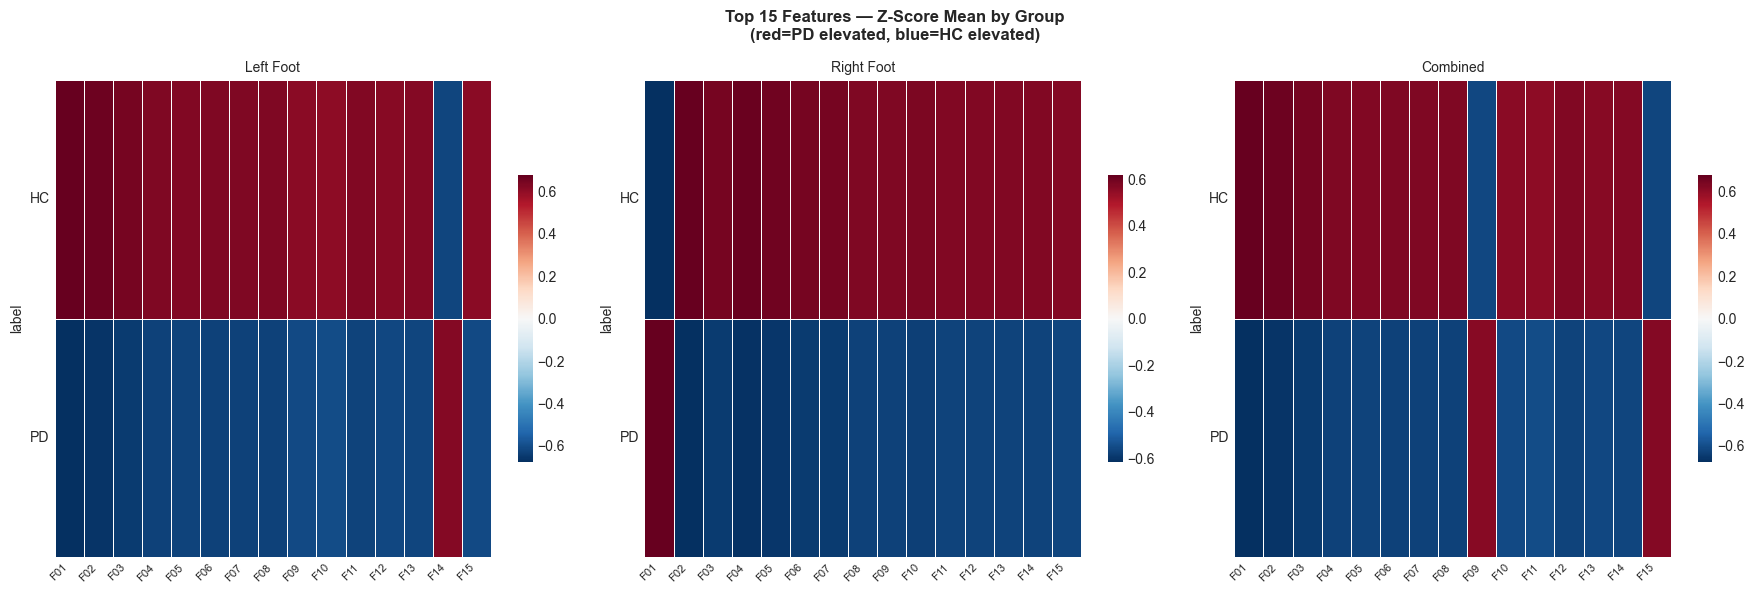

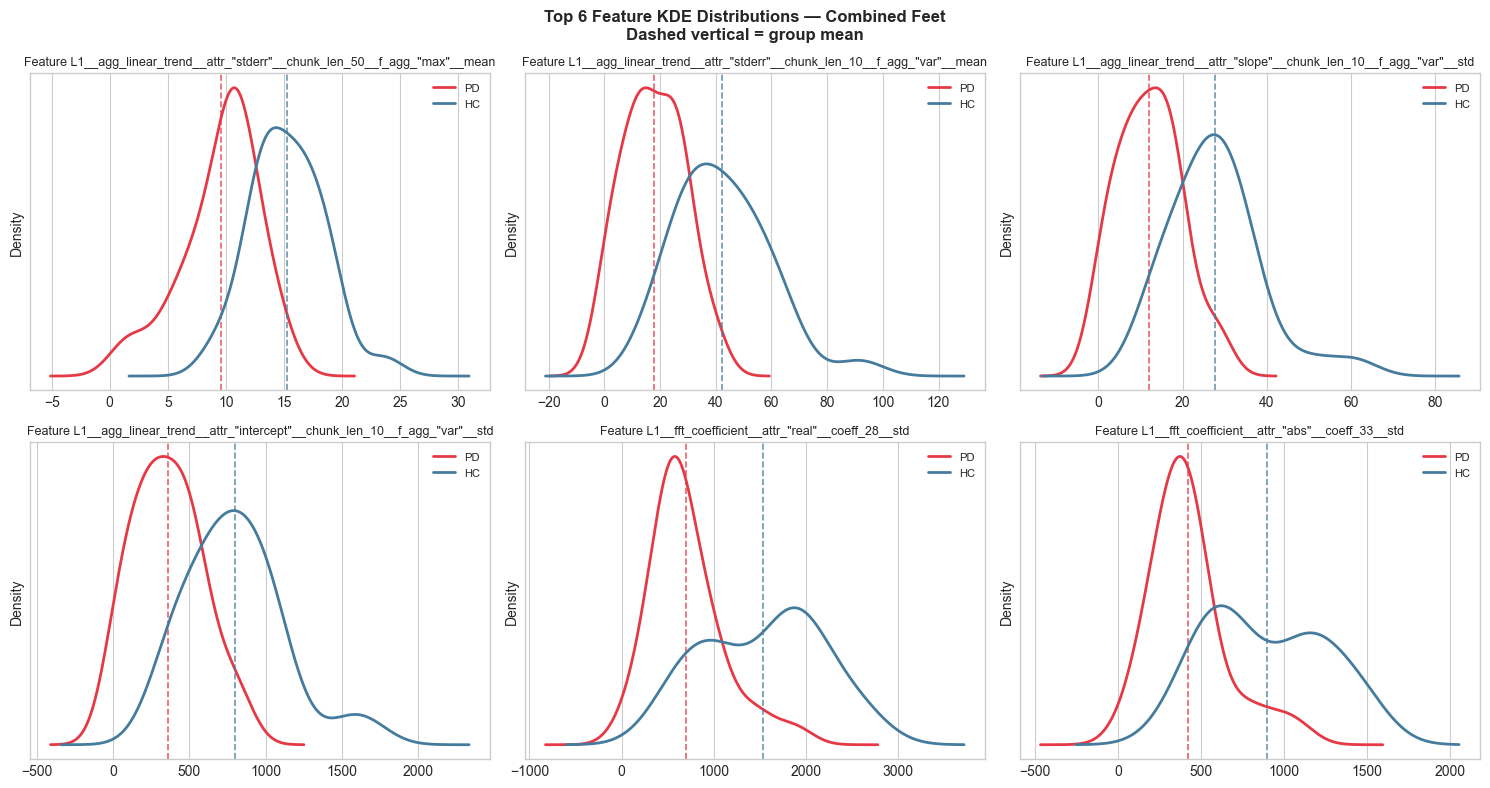

In [32]:
# ── 7C. Feature Heatmap & KDE Distributions ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 15 Features — Z-Score Mean by Group\n(red=PD elevated, blue=HC elevated)",
             fontsize=12, fontweight="bold")

for ax, sf, title in [(axes[0],left_sf,"Left Foot"),(axes[1],right_sf,"Right Foot"),(axes[2],comb_sf,"Combined")]:
    fcols_ = [c for c in sf.columns if c not in META]
    pd_d = sf[sf["label"]=="PD"][fcols_].fillna(0)
    hc_d = sf[sf["label"]=="HC"][fcols_].fillna(0)
    diff = (pd_d.mean()-hc_d.mean()).abs(); pool = (pd_d.std()+hc_d.std())/2+1e-9
    top  = (diff/pool).nlargest(15).index.tolist()
    sub  = sf[top+["label"]].fillna(0)
    sub_z = sub[top].copy()
    sub_z[top] = StandardScaler().fit_transform(sub_z.values)
    sub_z["label"] = sub["label"].values
    grp = sub_z.groupby("label")[top].mean()
    grp.columns = [f"F{i+1:02d}" for i in range(len(top))]
    sns.heatmap(grp, ax=ax, cmap="RdBu_r", center=0, linewidths=0.4,
                cbar_kws={"shrink":0.6}, yticklabels=["HC","PD"])
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# KDE distributions — combined, top 6
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Top 6 Feature KDE Distributions — Combined Feet\nDashed vertical = group mean",
             fontsize=12, fontweight="bold")
fcols_ = [c for c in comb_sf.columns if c not in META]
pd_d = comb_sf[comb_sf["label"]=="PD"][fcols_].fillna(0)
hc_d = comb_sf[comb_sf["label"]=="HC"][fcols_].fillna(0)
diff = (pd_d.mean()-hc_d.mean()).abs(); pool = (pd_d.std()+hc_d.std())/2+1e-9
top6 = (diff/pool).nlargest(6).index.tolist()

for ax, col in zip(axes.flat, top6):
    for lbl, clr in PALETTE.items():
        vals = comb_sf[comb_sf["label"]==lbl][col].dropna()
        try: vals.plot.kde(ax=ax, color=clr, label=lbl, linewidth=2)
        except: ax.hist(vals, color=clr, alpha=0.5, label=lbl, bins=8)
        ax.axvline(vals.mean(), color=clr, ls="--", lw=1.2, alpha=0.8)
    ax.set_title(f"Feature {col}", fontsize=9)
    ax.legend(fontsize=8); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 8. Summary of Outputs

| Figure | File | Description |
|---|---|---|
| Demographics (full) | `fig_demographics.png` | Age, cohort, H&Y — full dataset + fold |
| Raw signals | `fig_raw_signals.png` | 3 PD + 3 HC × 2 feet, 15s each |
| Variability | `fig_variability.png` | Rolling mean±SD, CV comparison |
| PCA left | `fig_pca_left_foot.png` | 3-panel PCA (A=diag, B=cohort, C=H&Y) |
| PCA right | `fig_pca_right_foot.png` | Same for right foot |
| PCA combined | `fig_pca_combined_feet.png` | Same for combined |
| t-SNE left | `fig_tsne_left_foot.png` | 2-panel t-SNE |
| t-SNE right | `fig_tsne_right_foot.png` | |
| t-SNE combined | `fig_tsne_combined_feet.png` | |
| UMAP combined | `fig_umap_combined.png` | Alternative: UMAP |
| Significance | `fig_significance.png` | Mann-Whitney U top features |
| Heatmap | `fig_feature_heatmap.png` | Z-score feature comparison |
| Distributions | `fig_feature_distributions.png` | KDE per feature |

### Key Design Decisions
- **Window:** 5s (500 samples) · **Step:** 2.5s (50% overlap)  
- **Z-score normalisation** applied to feature matrix before ALL dimensionality reduction  
- **Cohort confound** checked via panel B in every PCA/t-SNE plot  
- **SMOTE** will be applied only on training folds (not test) in subsequent deliverables


In [29]:
# List all output files
print("Generated output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:50s}  {sz//1024:>5} KB")


Generated output files:
  fig_age_distribution.png                               61 KB
  fig_cohort_distribution.png                            55 KB
  fig_demographics.png                                  146 KB
  fig_feature_distributions.png                         230 KB
  fig_feature_heatmap.png                                54 KB
  fig_hy_distribution.png                                54 KB
  fig_mean_gait_cycle.png                               409 KB
  fig_mean_gait_cycle_bilateral.png                     512 KB
  fig_overlay_raw_signals.png                           675 KB
  fig_pca_combined_feet.png                             123 KB
  fig_pca_left_foot.png                                 121 KB
  fig_pca_right_foot.png                                125 KB
  fig_raw_signals.png                                   713 KB
  fig_representative_raw_signals.png                    699 KB
  fig_significance.png                                  116 KB
  fig_tsne_combined_feet.png   